# Machine Learning 2 - Semestral Project
Petr Časar, Eliška Hrubošová, Marek Nikolić, Michal Jarolímek, Matyáš Pořízka, Lukáš Ptáčník 

In this project, we take on the role of a bookmaker for football bets. Specifically, our task is to create a classification model to predict whether 2.5 or more goals occur within a given match of football. The profit of our company is directly proportional to the accuracy of our model. Furthermore, we have basic data that is available to us at any time, and then augmented data with more columns, that we can purchase from a broker. The business focus of this task is thus figuring out how much we are willing to pay for the augmented data, based on the accuracy increase per country.

## Initialization and preprocessing
We start off by importing libraries we'll be using.

In [67]:
import pandas as pd
import os
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
from difflib import get_close_matches
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
import optuna
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn import svm
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import HistGradientBoostingClassifier
import plotly 
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
import tensorflow as tf
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter("ignore", category=pd.errors.PerformanceWarning)
np.seterr(all="ignore")

pd.set_option('display.max_columns', None) # to show all columns when displaying a DataFrame
# pd.reset_option('display.max_columns') # reset to default

Here we initialize a list of the countries we have data for and set a seed for reproducibility


In [68]:
countries = ["belgium", "england", "france", "germany","greece", "italy", "netherlands", "portugal","scotland", "spain","turkey"]
matches = 8
x = matches
SEED = 12
np.random.seed(SEED)
tf.random.set_seed(SEED)

## Data Exploration

In [69]:
### Loading data from all folders into one dataset - for simplification (else we'd have to do it for each league separately)
# Preserves the information about country, league and season
# To prevent data leakage, we skip the latest season "2324"

DATA_DIR = "data"
dfs = []
for country in os.listdir(DATA_DIR):
    country_path = os.path.join(DATA_DIR, country)
    if not os.path.isdir(country_path):
        continue
    for league in os.listdir(country_path):
        league_path = os.path.join(country_path, league)
        if not os.path.isdir(league_path):
            continue
        for file in os.listdir(league_path):
            if not file.endswith(".csv"):
                continue
            period = file.replace(".csv", "")
            if period == "2425":
                continue
            full_path = os.path.join(league_path, file)
            try:
                df = pd.read_csv(full_path)
                df.insert(0, "Period", period[:2])
                df.insert(0, "League", league)
                df.insert(0, "Country", country)
                dfs.append(df)
            except Exception as e:
                print(f"Error {full_path}: {e}")
data = pd.concat(dfs, ignore_index=True, join="outer")

data.head()


,Country,League,Period,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,HS,AS,HST,AST,HF,AF,HC,AC,HY,AY,HR,AR,B365H,B365D,B365A,BWH,BWD,BWA,IWH,IWD,IWA,PSH,PSD,PSA,WHH,WHD,WHA,VCH,VCD,VCA,MaxH,MaxD,MaxA,AvgH,AvgD,AvgA,B365>2.5,B365<2.5,P>2.5,P<2.5,Max>2.5,Max<2.5,Avg>2.5,Avg<2.5,AHh,B365AHH,B365AHA,PAHH,PAHA,MaxAHH,MaxAHA,AvgAHH,AvgAHA,B365CH,B365CD,B365CA,BWCH,BWCD,BWCA,IWCH,IWCD,IWCA,PSCH,PSCD,PSCA,WHCH,WHCD,WHCA,VCCH,VCCD,VCCA,MaxCH,MaxCD,MaxCA,AvgCH,AvgCD,AvgCA,B365C>2.5,B365C<2.5,PC>2.5,PC<2.5,MaxC>2.5,MaxC<2.5,AvgC>2.5,AvgC<2.5,AHCh,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA,Unnamed: 105,Referee,Unnamed: 106
0,belgium,1,19,B1,26/07/2019,19:30,Genk,Kortrijk,2,1,H,0.0,1.0,A,10.0,8.0,2.0,4.0,7.0,22.0,6.0,2.0,0.0,1.0,0.0,0.0,1.36,4.75,8.50,1.40,5.00,8.00,1.37,4.80,6.90,1.40,5.22,7.44,1.36,4.80,8.00,1.36,5.0,8.00,1.41,5.25,8.50,1.38,4.94,7.42,1.53,2.40,1.52,2.64,1.55,2.64,1.51,2.48,-1.50,2.07,1.72,2.04,1.85,2.12,1.85,2.05,1.79,1.45,4.75,6.50,1.40,5.00,8.0,1.45,4.60,5.90,1.45,4.94,6.79,1.42,4.75,6.50,1.45,4.8,6.50,1.47,5.00,8.00,1.43,4.80,6.51,1.50,2.50,1.52,2.64,1.53,2.65,1.49,2.53,-1.25,1.98,1.88,2.01,1.88,2.05,1.96,1.96,1.87,NaN,NaN,NaN
1,belgium,1,19,B1,27/07/2019,17:00,Cercle Brugge,Standard,0,2,A,0.0,0.0,D,13.0,14.0,5.0,9.0,16.0,15.0,3.0,7.0,2.0,2.0,1.0,0.0,3.75,3.75,1.85,3.80,3.75,1.95,3.70,3.60,1.87,3.91,3.63,1.99,3.70,3.60,1.91,3.75,3.7,1.93,4.10,3.80,1.99,3.72,3.59,1.93,1.75,2.05,1.81,2.05,1.82,2.17,1.74,2.06,0.50,1.93,1.93,1.90,1.98,1.96,1.98,1.90,1.93,3.75,3.80,1.85,4.00,3.75,1.91,3.55,3.65,1.90,3.79,3.74,1.99,3.75,3.70,1.88,3.60,3.9,1.95,4.10,3.95,2.01,3.71,3.70,1.92,1.61,2.25,1.66,2.30,1.69,2.32,1.63,2.24,0.50,1.88,1.98,1.91,1.99,1.95,2.02,1.89,1.94,NaN,NaN,NaN
2,belgium,1,19,B1,27/07/2019,19:00,St Truiden,Mouscron,0,1,A,0.0,1.0,A,10.0,10.0,4.0,6.0,10.0,21.0,5.0,5.0,2.0,4.0,0.0,0.0,1.90,3.75,3.75,1.95,3.50,4.10,1.93,3.45,3.65,1.99,3.52,4.04,1.91,3.60,3.75,1.93,3.6,3.80,2.01,3.75,4.10,1.95,3.49,3.77,1.80,2.00,1.88,1.98,1.88,2.07,1.82,1.98,-0.50,1.98,1.88,1.98,1.90,2.02,1.94,1.95,1.88,2.0,3.50,3.60,2.05,3.60,3.6,2.05,3.50,3.25,2.16,3.55,3.46,2.10,3.50,3.30,2.10,3.6,3.40,2.16,3.70,3.62,2.08,3.50,3.39,1.70,2.10,1.74,2.16,1.78,2.19,1.72,2.10,-0.25,1.83,2.02,1.87,2.03,1.88,2.07,1.83,2.02,NaN,NaN,NaN
3,belgium,1,19,B1,27/07/2019,19:00,Waregem,Mechelen,0,2,A,0.0,1.0,A,7.0,10.0,2.0,5.0,14.0,21.0,4.0,2.0,3.0,1.0,0.0,0.0,2.15,3.60,3.10,2.20,3.75,3.10,2.15,3.50,3.00,2.23,3.76,3.12,2.20,3.50,3.00,2.20,3.6,3.10,2.37,3.76,3.15,2.20,3.58,3.03,1.66,2.15,1.65,2.29,1.69,2.29,1.65,2.19,-0.25,1.93,1.93,1.95,1.93,1.97,1.96,1.92,1.91,2.8,3.40,2.50,2.70,3.60,2.55,2.65,3.50,2.40,2.80,3.59,2.51,2.62,3.50,2.45,2.75,3.7,2.40,2.80,3.70,2.61,2.66,3.53,2.48,1.60,2.30,1.60,2.42,1.67,2.42,1.61,2.28,0.25,1.72,2.07,1.75,2.17,1.80,2.28,1.72,2.15,NaN,NaN,NaN
4,belgium,1,19,B1,27/07/2019,19:30,Waasland-Beveren,Club Brugge,1,3,A,1.0,1.0,D,7.0,25.0,2.0,22.0,18.0,12.0,1.0,14.0,3.0,1.0,0.0,0.0,6.50,4.00,1.50,6.00,4.50,1.53,5.30,4.30,1.50,5.52,4.59,1.56,5.50,4.33,1.52,5.75,4.5,1.50,6.50,4.60,1.59,5.53,4.36,1.53,1.57,2.35,1.55,2.50,1.58,2.50,1.55,2.38,1.00,1.98,1.88,1.96,1.93,2.04,1.94,1.96,1.87,12.0,5.75,1.25,10.00,6.00,1.3,9.20,5.70,1.26,8.99,6.52,1.29,10.00,6.00,1.24,12.00,6.0,1.25,12.00,6.55,1.33,9.44,5.89,1.27,1.44,2.70,1.42,2.97,1.50,2.98,1.43,2.73,1.50,2.20,1.70,2.19,1.74,2.25,1.83,2.11,1.74,NaN,NaN,NaN


In [70]:
df=data # to preserve the original raw dataset for any case
df.shape

(35464, 111)

In [71]:
df.describe()

,FTHG,FTAG,HTHG,HTAG,HS,AS,HST,AST,HF,AF,HC,AC,HY,AY,HR,AR,B365H,B365D,B365A,BWH,BWD,BWA,IWH,IWD,IWA,PSH,PSD,PSA,WHH,WHD,WHA,VCH,VCD,VCA,MaxH,MaxD,MaxA,AvgH,AvgD,AvgA,B365>2.5,B365<2.5,P>2.5,P<2.5,Max>2.5,Max<2.5,Avg>2.5,Avg<2.5,AHh,B365AHH,B365AHA,PAHH,PAHA,MaxAHH,MaxAHA,AvgAHH,AvgAHA,B365CD,B365CA,BWCH,BWCD,IWCH,IWCD,IWCA,PSCH,PSCD,PSCA,WHCH,WHCD,WHCA,VCCH,VCCD,VCCA,MaxCH,MaxCD,MaxCA,AvgCH,AvgCD,AvgCA,B365C>2.5,B365C<2.5,PC>2.5,PC<2.5,MaxC>2.5,MaxC<2.5,AvgC>2.5,AvgC<2.5,AHCh,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA,Unnamed: 105,Unnamed: 106
count,35464.000000,35464.000000,35426.000000,35426.00000,35424.000000,35424.000000,35424.000000,35424.000000,35422.000000,35422.000000,35424.000000,35424.000000,35426.000000,35426.000000,35426.000000,35426.000000,35347.000000,35347.000000,35347.000000,35066.000000,35066.000000,35066.000000,31729.000000,31729.000000,31729.000000,35278.000000,35278.000000,35278.000000,34094.000000,34094.000000,34094.000000,35221.000000,35221.000000,35221.000000,35418.000000,35418.000000,35418.000000,35418.000000,35418.000000,35418.000000,35335.000000,35335.000000,35207.000000,35207.000000,35417.000000,35417.000000,35417.000000,35417.000000,35398.000000,35162.000000,35161.000000,35278.000000,35279.000000,35416.000000,35416.000000,35417.000000,35417.000000,35404.000000,35404.000000,35093.000000,35093.000000,31743.000000,31743.000000,31743.000000,35411.000000,35411.000000,35411.000000,34160.000000,34160.000000,34160.000000,35393.000000,35393.000000,35393.000000,35432.000000,35432.000000,35432.000000,35432.000000,35432.000000,35432.000000,35400.000000,35400.000000,35351.000000,35351.000000,35432.000000,35432.000000,35432.000000,35432.000000,35431.000000,35375.000000,35375.000000,35410.000000,35410.000000,35431.000000,35431.000000,35432.000000,35432.000000,0.0,0.0
mean,1.465486,1.197581,0.654717,0.53249,12.867293,10.875339,4.575796,3.848747,12.360793,12.576365,5.312077,4.481736,1.914103,2.130836,0.091712,0.111923,2.627595,3.761136,3.953814,2.597002,3.731389,3.878237,2.606636,3.664695,3.821689,2.704792,3.861267,4.134022,2.629087,3.674485,3.988958,2.636422,3.714855,3.994023,2.791535,3.987210,4.326854,2.628223,3.751943,3.933339,1.954950,1.947799,1.992961,1.982943,2.030170,2.029800,1.947922,1.945474,-0.258567,1.938784,1.933285,1.953468,1.942371,1.987046,1.979846,1.920939,1.912411,3.780083,3.986283,2.634093,3.733352,2.635906,3.652926,3.848920,2.753748,3.870078,4.221320,2.666717,3.686431,4.034950,2.676883,3.762447,4.037169,2.874872,4.016745,4.460202,2.666442,3.758580,3.994198,1.975071,1.953948,2.017676,1.993302,2.070193,2.059059,1.965769,1.952346,-0.253606,1.932528,1.939306,1.950292,1.955764,2.001189,2.006340,1.918421,1.921437,NaN,NaN
std,1.257095,1.140480,0.818393,0.74195,5.143507,4.658151,2.499473,2.274165,4.108310,4.136777,2.871147,2.621102,1.375208,1.423153,0.306091,0.339006,1.555609,0.986010,2.763479,1.507452,0.996959,2.793047,1.472042,0.942887,2.615668,1.625784,1.099075,3.144815,1.637617,0.926709,3.145232,1.629615,0.972610,3.030546,1.861577,1.182848,3.682710,1.550105,0.997175,2.867277,0.322262,0.395848,0.340169,0.397819,0.345168,0.427249,0.319225,0.389200,0.687114,0.098690,0.096939,0.099785,0.098267,0.096306,0.095419,0.091094,0.090390,1.060669,2.843487,1.607907,1.088315,1.542319,0.980054,2.628605,1.783231,1.215725,3.347348,1.750974,1.013578,3.237141,1.730104,1.072802,3.126948,2.036128,1.326832,3.915383,1.648414,1.081743,2.987072,0.368631,0.446697,0.381562,0.446418,0.390052,0.491559,0.356192,0.435680,0.708549,0.104225,0.100764,0.104056,0.102974,0.104486,0.105695,0.095036,0.093276,NaN,NaN
min,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.910000,1.050000,1.020000,1.850000,1.010000,1.040000,1.900000,1.060000,1.020000,1.970000,1.070000,1.020000,2.200000,1.030000,1.030000,1.830000,1.060000,1.030000,2.020000,1.060000,1.020000,1.880000,1.030000,1.100000,1.220000,1.100000,1.280000,1.110000,1.28

##### Validating text columns
First I want to check all the text columns and try to find possible typos which could lead to duplicities. For this I will use difflib function get_close_matches, which will be able to return similar enough cases and should cover typos and mistranslations.

In [72]:
# just checking how many unique teams and referees there are, so the computation isn´t imeasurable (:
print(df["HomeTeam"].nunique(),df["AwayTeam"].nunique(),df["Referee"].nunique())

462 462 214


In [73]:
text_cols = ["HomeTeam", "AwayTeam", "Referee"]

# text preprocessing function (lowercase, remove spaces, special chars)
def preprocess_text(column):
    column = column.fillna("").astype(str)
    column = column.str.strip()
    column = column.str.replace("-", " ")
    column = column.str.replace("\n", "")
    column = column.str.replace("\t", "")
    column = column.str.lower()
    return column

for col in text_cols:
    df[col] = preprocess_text(df[col])

# function for searching similar entities in a list of unique names
def get_similar_entities(unique_names):
    matches = []
    unique_names = [str(x) for x in unique_names if x != ""]
    for i, name in enumerate(unique_names):
        possible_match = get_close_matches(name, unique_names[i+1:], cutoff=0.7)
        if possible_match:
            matches.append((name, possible_match))
    return matches

# for both unique away and home teams together
unique_teams = pd.concat([df["HomeTeam"], df["AwayTeam"]]).unique()
print("\nSimilarities for Teams:")
for base, similars in get_similar_entities(unique_teams):
    print(f" - {base} -> {', '.join(similars)}")

# for unique referees
unique_refs = df["Referee"].unique()
print("\nSimilarities for Referees:")
for base, similars in get_similar_entities(unique_refs):
    print(f" - {base} -> {', '.join(similars)}")
 


Similarities for Teams:
 - genk -> gent
 - cercle brugge -> club brugge
 - st truiden -> st etienne
 - charleroi -> charlton
 - standard -> santander
 - mouscron -> morton
 - seraing -> reading
 - westerlo -> west brom
 - west ham -> west brom
 - burnley -> barnsley
 - watford -> salford
 - brighton -> burton
 - everton -> verona
 - southampton -> northampton, sutton
 - sheffield united -> sheffield weds
 - chelsea -> cheltenham
 - brentford -> bradford
 - luton -> sutton, burton, bolton
 - birmingham -> gillingham
 - charlton -> hamilton
 - tranmere -> stranraer
 - bolton -> bologna
 - bristol rvs -> raith rvs
 - leyton orient -> lorient
 - newport county -> notts county
 - macclesfield -> mansfield
 - oldham -> volendam
 - harrogate -> arbroath
 - notts county -> ross county
 - monaco -> monza
 - angers -> rangers
 - paris sg -> paris fc
 - lens -> orleans, leganes, le mans
 - nancy -> annecy
 - le mans -> orleans, leganes
 - orleans -> leganes
 - paris fc -> pau fc
 - valenciennes 

In [74]:
df.loc[df["Referee"].isin(["p stuart","p  stuart",
                           "l watson","l lwatson",
                           "r welch","r  welch"
                           ]),["Referee","Country"]].value_counts() # seems really just like typos

Referee    Country 
p stuart   scotland    98
r welch    england     49
l watson   scotland     8
l lwatson  scotland     1
p  stuart  scotland     1
r  welch   england      1
Name: count, dtype: int64

In [75]:
# fixing the typos found
df["Referee"] = df["Referee"].replace({
    "p  stuart": "p stuart",
    "l lwatson": "l watson",
    "r  welch": "r  welch"})


In [76]:
# it seems no team has ever played against itself
print((df["HomeTeam"] == df["AwayTeam"]).sum())

0


##### Validating numeric colums
Checking easy-to-find inconsistencies in the dataset

In [77]:
# was there any match with total goals >20?
print((df["FTHG"] + df["FTAG"] > 20).sum())

0


In [78]:
# or more goals in first half than in whole match?
print((df["HTHG"] + df["HTAG"] > df["FTHG"] + df["FTAG"]).sum())

0


In [79]:
# or more shots on target than total shots?
print((df["HST"] + df["AST"] > df["HS"] + df["AS"]).sum())
# probably no stupid mistakes in this dataset :(

0


##### Feature engeneering

In [80]:
def unillegal_columns(df):
    df.columns = df.columns.str.replace('>', 'above', regex=False)
    df.columns = df.columns.str.replace('<', 'below', regex=False)
    return df
def to_datetime(df):
    df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month
    df['Day'] = df['Date'].dt.day
    df['IsWeekend'] = df['Date'].dt.dayofweek >= 5
    df['TimeNumeric'] = pd.to_datetime(df['Time'], format='%H:%M').apply(lambda x: x.hour + x.minute/60)
    return df
def days_since_season_start(df):
    season_start = df['Date'].min()
    df['DaysFromSeasonStart'] = ((df['Date'] - season_start).dt.days % 365)
    return df
def days_since_last_match(df):
    home = df[['Date', 'HomeTeam']].rename(columns={'HomeTeam': 'Team'})
    away = df[['Date', 'AwayTeam']].rename(columns={'AwayTeam': 'Team'})
    
    long_df = pd.concat([home, away]).sort_values(['Team', 'Date'])
    long_df['LastMatchDate'] = long_df.groupby('Team')['Date'].shift(1)
    homelastmatch= df.apply(
        lambda row: long_df.loc[(long_df['Team'] == row['HomeTeam']) & (long_df['Date'] < row['Date']), 'LastMatchDate'].max(),
        axis=1
    )
    
    awaylastmatch = df.apply(
        lambda row: long_df.loc[(long_df['Team'] == row['AwayTeam']) & (long_df['Date'] < row['Date']), 'LastMatchDate'].max(),
        axis=1
    )

    df['DaysSinceLastMatchAway'] = (df['Date'] - awaylastmatch).dt.days.fillna(365)
    df['DaysSinceLastMatchHome'] = (df['Date'] - homelastmatch).dt.days.fillna(365)
    df['DaysSinceLastMatchDiff'] = abs(df['DaysSinceLastMatchHome'] - df['DaysSinceLastMatchAway'])
    
    return df
def days_since_last_match_eda(df): # less computationally demanding version for initial EDA
    df = df.dropna(subset=['FTHG']).copy()
    df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y', errors='coerce') 
    home_matches = df[['Date', 'HomeTeam']].rename(columns={'HomeTeam': 'Team'})
    away_matches = df[['Date', 'AwayTeam']].rename(columns={'AwayTeam': 'Team'})
    
    long_df = pd.concat([home_matches, away_matches])
    long_df = long_df.sort_values(['Team', 'Date']).reset_index(drop=True)
    long_df['LastMatchDate'] = long_df.groupby('Team')['Date'].shift(1)
    long_df = long_df.drop_duplicates(subset=['Team', 'Date'], keep='first')
    
    df = pd.merge(
        df, 
        long_df.rename(columns={'Team': 'HomeTeam', 'LastMatchDate': 'HomeLastMatchDate'}), 
        on=['HomeTeam', 'Date'], 
        how='left')
    
    df = pd.merge(
        df, 
        long_df.rename(columns={'Team': 'AwayTeam', 'LastMatchDate': 'AwayLastMatchDate'}), 
        on=['AwayTeam', 'Date'], 
        how='left')
    
    df['DaysSinceLastMatchHome'] = (df['Date'] - df['HomeLastMatchDate']).dt.days    
    df['DaysSinceLastMatchAway'] = (df['Date'] - df['AwayLastMatchDate']).dt.days
    df['DaysSinceLastMatchHome'] = df['DaysSinceLastMatchHome'].fillna(365)
    df['DaysSinceLastMatchAway'] = df['DaysSinceLastMatchAway'].fillna(365)    
    df['DaysSinceLastMatchDiff'] = abs(df['DaysSinceLastMatchHome'] - df['DaysSinceLastMatchAway'])    
    df = df.drop(columns=['HomeLastMatchDate', 'AwayLastMatchDate'])
    
    return df
def get_season_from_month(df):
    month_to_season = {
        1: 'Winter', 2: 'Winter', 12: 'Winter',
        3: 'Spring', 4: 'Spring', 5: 'Spring',
        6: 'Summer', 7: 'Summer', 8: 'Summer',
        9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
    }
    
    df['Season'] = df['Date'].dt.month.map(month_to_season)
    season_dummies = pd.get_dummies(df['Season'], prefix='Season')
    df = pd.concat([df, season_dummies], axis=1).drop(columns=['Season'])
    
    return df
def get_season_from_month_eda(df):
    month_to_season = {
        1: 'Winter', 2: 'Winter', 12: 'Winter',
        3: 'Spring', 4: 'Spring', 5: 'Spring',
        6: 'Summer', 7: 'Summer', 8: 'Summer',
        9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
    }
    df['Season'] = df['Date'].dt.month.map(month_to_season)    
    return df
def add_target_variable(df):
    df['Target'] = (df['FTHG'] + df['FTAG'] > 2.5).astype(int)
    return df
def bool_to_int(df):
    df[df.select_dtypes(include='bool').columns] = df.select_dtypes(include='bool').astype(int)
    return df

In [81]:
def last_x_matches_agg(df, x, home_col='HomeTeam', away_col='AwayTeam'):
    df = df.sort_values(by='Date').reset_index(drop=True)

    # Prepare long-form DataFrame for home and away matches
    home = df[['Div', 'Date', home_col, 'FTHG']].rename(
        columns={home_col: 'Team', 'FTHG': 'Goals'}
    )
    away = df[['Div', 'Date', away_col, 'FTAG']].rename(
        columns={away_col: 'Team', 'FTAG': 'Goals'}
    )

    long_df = pd.concat([home, away]).sort_values(['Div', 'Team', 'Date'])

    # Compute rolling mean per Division and Team
    long_df[f'AvgLast{x}_GoalsAgg'] = (
        long_df.groupby(['Div', 'Team'])['Goals']
               .apply(lambda s: s.shift().rolling(window=x, min_periods=1).mean())
               .reset_index(level=[0, 1], drop=True)
    )

    # Merge back for Home teams
    df = df.merge(
        long_df[['Div', 'Team', 'Date', f'AvgLast{x}_GoalsAgg']],
        left_on=['Div', home_col, 'Date'],
        right_on=['Div', 'Team', 'Date'],
        how='left'
    ).rename(columns={f'AvgLast{x}_GoalsAgg': f'AvgLast{x}HomeGoalsAgg'}).drop(columns='Team')

    # Merge back for Away teams
    df = df.merge(
        long_df[['Div', 'Team', 'Date', f'AvgLast{x}_GoalsAgg']],
        left_on=['Div', away_col, 'Date'],
        right_on=['Div', 'Team', 'Date'],
        how='left'
    ).rename(columns={f'AvgLast{x}_GoalsAgg': f'AvgLast{x}AwayGoalsAgg'}).drop(columns='Team')

    return df

def last_x_matches(df, x):
    df = df.sort_values(by='Date').reset_index(drop=True)

    df[f'AvgLast{x}HomeGoals'] = (
        df.groupby(['Div', 'HomeTeam'])['FTHG']
          .apply(lambda s: s.shift().rolling(window=x, min_periods=1).mean())
          .reset_index(level=[0, 1], drop=True)
    )

    df[f'AvgLast{x}AwayGoals'] = (
        df.groupby(['Div', 'AwayTeam'])['FTAG']
          .apply(lambda s: s.shift().rolling(window=x, min_periods=1).mean())
          .reset_index(level=[0, 1], drop=True)
    )

    return df

def last_x_matches_agg_test(test_df, train_df, x):
    test_df = test_df.copy()

    # Last known home averages per Division & Team
    last_home_vals = (
        train_df[['Div', 'HomeTeam', f'AvgLast{x}HomeGoalsAgg']]
        .dropna()
        .groupby(['Div', 'HomeTeam'])[f'AvgLast{x}HomeGoalsAgg']
        .last()
    )

    # Last known away averages per Division & Team
    last_away_vals = (
        train_df[['Div', 'AwayTeam', f'AvgLast{x}AwayGoalsAgg']]
        .dropna()
        .groupby(['Div', 'AwayTeam'])[f'AvgLast{x}AwayGoalsAgg']
        .last()
    )

    # Map both home and away values within the same division
    test_df[f'AvgLast{x}HomeGoalsAgg'] = test_df.set_index(['Div', 'HomeTeam']).index.map(last_home_vals)
    test_df[f'AvgLast{x}AwayGoalsAgg'] = test_df.set_index(['Div', 'AwayTeam']).index.map(last_away_vals)

    return test_df


def last_x_matches_test(test_df, train_df, x):
    test_df = test_df.copy()

    # Last known home averages per Division & Team
    last_home_vals = (
        train_df[['Div', 'HomeTeam', f'AvgLast{x}HomeGoals']]
        .dropna()
        .groupby(['Div', 'HomeTeam'])[f'AvgLast{x}HomeGoals']
        .last()
    )

    # Last known away averages per Division & Team
    last_away_vals = (
        train_df[['Div', 'AwayTeam', f'AvgLast{x}AwayGoals']]
        .dropna()
        .groupby(['Div', 'AwayTeam'])[f'AvgLast{x}AwayGoals']
        .last()
    )

    # Map both home and away averages by (Div, Team)
    test_df[f'AvgLast{x}HomeGoals'] = test_df.set_index(['Div', 'HomeTeam']).index.map(last_home_vals)
    test_df[f'AvgLast{x}AwayGoals'] = test_df.set_index(['Div', 'AwayTeam']).index.map(last_away_vals)

    return test_df

def new_players_agg(df, x):
    df = df.sort_values(['Div', 'Date']).reset_index(drop=True)

    # Fill home missing values safely
    df[f'AvgLast{x}HomeGoalsAgg'] = df.groupby('Div', group_keys=False).apply(
        lambda g: g.assign(
            **{
                f'AvgLast{x}HomeGoalsAgg': g[f'AvgLast{x}HomeGoalsAgg'].fillna(
                    ((g['FTHG'] + g['FTAG']) / 2)
                    .expanding(min_periods=1).mean().shift(1)
                )
            }
        )
    )[f'AvgLast{x}HomeGoalsAgg']

    # Fill away missing values safely
    df[f'AvgLast{x}AwayGoalsAgg'] = df.groupby('Div', group_keys=False).apply(
        lambda g: g.assign(
            **{
                f'AvgLast{x}AwayGoalsAgg': g[f'AvgLast{x}AwayGoalsAgg'].fillna(
                    ((g['FTHG'] + g['FTAG']) / 2)
                    .expanding(min_periods=1).mean().shift(1)
                )
            }
        )
    )[f'AvgLast{x}AwayGoalsAgg']

    return df

def new_players(df, x):
    df = df.sort_values(['Div', 'Date']).reset_index(drop=True)

    # For missing home values
    df[f'AvgLast{x}HomeGoals'] = df.groupby('Div', group_keys=False).apply(
        lambda g: g.assign(
            **{
                f'AvgLast{x}HomeGoals': g[f'AvgLast{x}HomeGoals'].fillna(
                    g['FTHG'].expanding(min_periods=1).mean().shift(1)
                )
            }
        )
    )[f'AvgLast{x}HomeGoals']

    # For missing away values
    df[f'AvgLast{x}AwayGoals'] = df.groupby('Div', group_keys=False).apply(
        lambda g: g.assign(
            **{
                f'AvgLast{x}AwayGoals': g[f'AvgLast{x}AwayGoals'].fillna(
                    g['FTAG'].expanding(min_periods=1).mean().shift(1)
                )
            }
        )
    )[f'AvgLast{x}AwayGoals']

    return df

def new_players_test_agg(test_df, train_df, x):
    div_means = (train_df.groupby('Div')['FTHG'].mean() + train_df.groupby('Div')['FTAG'].mean()) / 2

    test_df[f'AvgLast{x}HomeGoalsAgg'] = test_df[f'AvgLast{x}HomeGoalsAgg'].fillna(
    test_df['Div'].map(div_means)
    )
    test_df[f'AvgLast{x}AwayGoalsAgg'] = test_df[f'AvgLast{x}AwayGoalsAgg'].fillna(
    test_df['Div'].map(div_means)
    )
    return test_df

def new_players_test(test_df, train_df, x):
    div_means_home = train_df.groupby('Div')['FTHG'].mean()
    div_means_away = train_df.groupby('Div')['FTAG'].mean()

    test_df[f'AvgLast{x}HomeGoals'] = test_df[f'AvgLast{x}HomeGoals'].fillna(
    test_df['Div'].map(div_means_home)
    )
    test_df[f'AvgLast{x}AwayGoals'] = test_df[f'AvgLast{x}AwayGoals'].fillna(
    test_df['Div'].map(div_means_away)
    )
    return test_df

def last_x_matches_total(df, x):
    df[f'AvgLast{x}Goals'] = df[f'AvgLast{x}HomeGoals'] + df[f'AvgLast{x}AwayGoals']
    return df

def last_x_matches_total_agg(df, x):
    df[f'AvgLast{x}GoalsAgg'] = df[f'AvgLast{x}HomeGoalsAgg'] + df[f'AvgLast{x}AwayGoalsAgg']
    return df

In [82]:
df = unillegal_columns(df)
df = to_datetime(df)
df = days_since_season_start(df)
df = days_since_last_match_eda(df)
df = get_season_from_month_eda(df)
df = add_target_variable(df)
df = bool_to_int(df)
df = last_x_matches_agg(df, x)
df = last_x_matches(df, x)
df = new_players_agg(df, x)
df = new_players(df, x)
df = last_x_matches_total_agg(df, x)
df = last_x_matches_total(df, x)

#### Exploratory data analysis

In [83]:
df.describe()

,Date,FTHG,FTAG,HTHG,HTAG,HS,AS,HST,AST,HF,AF,HC,AC,HY,AY,HR,AR,B365H,B365D,B365A,BWH,BWD,BWA,IWH,IWD,IWA,PSH,PSD,PSA,WHH,WHD,WHA,VCH,VCD,VCA,MaxH,MaxD,MaxA,AvgH,AvgD,AvgA,B365above2.5,B365below2.5,Pabove2.5,Pbelow2.5,Maxabove2.5,Maxbelow2.5,Avgabove2.5,Avgbelow2.5,AHh,B365AHH,B365AHA,PAHH,PAHA,MaxAHH,MaxAHA,AvgAHH,AvgAHA,B365CD,B365CA,BWCH,BWCD,IWCH,IWCD,IWCA,PSCH,PSCD,PSCA,WHCH,WHCD,WHCA,VCCH,VCCD,VCCA,MaxCH,MaxCD,MaxCA,AvgCH,AvgCD,AvgCA,B365Cabove2.5,B365Cbelow2.5,PCabove2.5,PCbelow2.5,MaxCabove2.5,MaxCbelow2.5,AvgCabove2.5,AvgCbelow2.5,AHCh,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA,Unnamed: 105,Unnamed: 106,Year,Month,Day,IsWeekend,TimeNumeric,DaysFromSeasonStart,DaysSinceLastMatchHome,DaysSinceLastMatchAway,DaysSinceLastMatchDiff,Target,AvgLast8HomeGoalsAgg,AvgLast8AwayGoalsAgg,AvgLast8HomeGoals,AvgLast8AwayGoals,AvgLast8GoalsAgg,AvgLast8Goals
count,35464,35464.000000,35464.000000,35426.000000,35426.00000,35424.000000,35424.000000,35424.000000,35424.000000,35422.000000,35422.000000,35424.000000,35424.000000,35426.000000,35426.000000,35426.000000,35426.000000,35347.000000,35347.000000,35347.000000,35066.000000,35066.000000,35066.000000,31729.000000,31729.000000,31729.000000,35278.000000,35278.000000,35278.000000,34094.000000,34094.000000,34094.000000,35221.000000,35221.000000,35221.000000,35418.000000,35418.000000,35418.000000,35418.000000,35418.000000,35418.000000,35335.000000,35335.000000,35207.000000,35207.000000,35417.000000,35417.000000,35417.000000,35417.000000,35398.000000,35162.000000,35161.000000,35278.000000,35279.000000,35416.000000,35416.000000,35417.000000,35417.000000,35404.000000,35404.000000,35093.000000,35093.000000,31743.000000,31743.000000,31743.000000,35411.000000,35411.000000,35411.000000,34160.000000,34160.000000,34160.000000,35393.000000,35393.000000,35393.000000,35432.000000,35432.000000,35432.000000,35432.000000,35432.000000,35432.000000,35400.000000,35400.000000,35351.000000,35351.000000,35432.000000,35432.000000,35432.000000,35432.000000,35431.000000,35375.000000,35375.000000,35410.000000,35410.000000,35431.000000,35431.000000,35432.000000,35432.000000,0.0,0.0,35464.000000,35464.000000,35464.000000,35464.000000,35464.000000,35464.000000,35464.000000,35464.000000,35464.000000,35464.000000,35443.000000,35443.000000,35443.000000,35443.000000,35443.000000,35443.000000
mean,2022-01-20 14:35:01.691856384,1.465486,1.197581,0.654717,0.53249,12.867293,10.875339,4.575796,3.848747,12.360793,12.576365,5.312077,4.481736,1.914103,2.130836,0.091712,0.111923,2.627595,3.761136,3.953814,2.597002,3.731389,3.878237,2.606636,3.664695,3.821689,2.704792,3.861267,4.134022,2.629087,3.674485,3.988958,2.636422,3.714855,3.994023,2.791535,3.987210,4.326854,2.628223,3.751943,3.933339,1.954950,1.947799,1.992961,1.982943,2.030170,2.029800,1.947922,1.945474,-0.258567,1.938784,1.933285,1.953468,1.942371,1.987046,1.979846,1.920939,1.912411,3.780083,3.986283,2.634093,3.733352,2.635906,3.652926,3.848920,2.753748,3.870078,4.221320,2.666717,3.686431,4.034950,2.676883,3.762447,4.037169,2.874872,4.016745,4.460202,2.666442,3.758580,3.994198,1.975071,1.953948,2.017676,1.993302,2.070193,2.059059,1.965769,1.952346,-0.253606,1.932528,1.939306,1.950292,1.955764,2.001189,2.006340,1.918421,1.921437,NaN,NaN,2021.561584,6.446425,15.698539,0.713851,16.505433,161.874323,11.703220,11.686809,2.181705,0.498477,1.318373,1.336027,1.462943,1.193292,2.654400,2.656236
min,2019-07-26 00:00:00,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.910000,1.050000,1.020000,1.850000,1.010000,1.040000,1.900000,1.060000,1.020000,1.970000,1.070000,1.020000,2.200000,1.030000,1.030000,1.830000,1.060000,1.030000,2.020000,1.060000,1.020000,1.880000,1.030000,1.100000,1.220000,1.100000,1.280000,1.110000,1.280000,1.090000,1.230000,-3.750000,1.050000,1.270000,1.560000,1.320000,1.690000,1.330000,1.630000,0.000000,1.530000,1.030000,1.020000,2.050000,1.0200

In [84]:
df["Month"] = pd.Categorical(df["Month"], categories=list(range(1, 13)), ordered=True)

print(df.dtypes)

Country                         object
League                          object
Period                          object
Div                             object
Date                    datetime64[ns]
                             ...      
AvgLast8AwayGoalsAgg           float64
AvgLast8HomeGoals              float64
AvgLast8AwayGoals              float64
AvgLast8GoalsAgg               float64
AvgLast8Goals                  float64
Length: 128, dtype: object


In [85]:
# table with percentage of NA values per column, grouped by Div
def nan_percentage(series):
    return (series.isna().sum() / len(series)) * 100

nan_by_div = df.groupby('Div').agg(nan_percentage).round(1)
nan_by_div.index.name = 'Liga/Země'
total_nan_series = df.agg(nan_percentage).round(1)
total_nan_df = pd.DataFrame(total_nan_series).T
total_nan_df.index = ['(df)']

final_nan_overview = pd.concat([nan_by_div, total_nan_df])
display(final_nan_overview)

,Country,League,Period,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,HS,AS,HST,AST,HF,AF,HC,AC,HY,AY,HR,AR,B365H,B365D,B365A,BWH,BWD,BWA,IWH,IWD,IWA,PSH,PSD,PSA,WHH,WHD,WHA,VCH,VCD,VCA,MaxH,MaxD,MaxA,AvgH,AvgD,AvgA,B365above2.5,B365below2.5,Pabove2.5,Pbelow2.5,Maxabove2.5,Maxbelow2.5,Avgabove2.5,Avgbelow2.5,AHh,B365AHH,B365AHA,PAHH,PAHA,MaxAHH,MaxAHA,AvgAHH,AvgAHA,B365CH,B365CD,B365CA,BWCH,BWCD,BWCA,IWCH,IWCD,IWCA,PSCH,PSCD,PSCA,WHCH,WHCD,WHCA,VCCH,VCCD,VCCA,MaxCH,MaxCD,MaxCA,AvgCH,AvgCD,AvgCA,B365Cabove2.5,B365Cbelow2.5,PCabove2.5,PCbelow2.5,MaxCabove2.5,MaxCbelow2.5,AvgCabove2.5,AvgCbelow2.5,AHCh,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA,Unnamed: 105,Referee,Unnamed: 106,Year,Month,Day,IsWeekend,TimeNumeric,DaysFromSeasonStart,DaysSinceLastMatchHome,DaysSinceLastMatchAway,DaysSinceLastMatchDiff,Season,Target,AvgLast8HomeGoalsAgg,AvgLast8AwayGoalsAgg,AvgLast8HomeGoals,AvgLast8AwayGoals,AvgLast8GoalsAgg,AvgLast8Goals,Div
B1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.3,0.3,0.3,0.3,0.3,0.3,0.3,0.3,0.3,0.3,0.3,0.3,0.3,0.3,0.3,0.1,0.1,0.1,0.2,0.2,0.2,10.4,10.4,10.4,0.3,0.3,0.3,23.7,23.7,23.7,1.8,1.8,1.8,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.1,0.3,0.3,0.0,0.0,0.0,0.0,0.0,0.3,0.3,0.3,0.3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.5,0.5,10.4,10.4,10.4,0.0,0.0,0.0,24.1,24.1,24.1,1.1,1.1,1.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.1,0.1,0.1,0.1,0.1,NaN
D1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.6,0.6,0.6,10.7,10.7,10.7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.5,2.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.1,0.0,0.0,0.0,0.0,0.0,0.6,0.6,0.6,11.3,11.3,11.3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.2,2.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.1,0.1,0.1,0.1,0.1,NaN
D2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.2,0.2,0.2,0.7,0.7,0.7,10.1,10.1,10.1,0.4,0.4,0.4,0.1,0.1,0.1,0.1,0.1,0.1,0.0,0.0,0.0,0.0,0.0,0.0,0.3,0.3,0.4,0.4,0.0,0.0,0.0,0.0,0.0,0.3,0.3,0.4,0.4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.7,0.7,0.7,10.7,10.7,10.7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.1,0.1,0.1,0.1,0.1,NaN
E0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.1,0.1,9.6,9.6,9.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.1,0.5,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.6,0.6,0.6,9.7,9.7,9.7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.4,0.4,0.0,0.0,0.0,0.0,0.0,0.1,0.1,0.0,0.0,0.1,0.1,0.0,0.0,100.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.1,0.1,0.1,0.1,0.1,NaN
E1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.1,0.1,9.1,9.1,9.1,0.1,0.1,0.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.7,0.7,0.7,8.7,8.7,8.7,0.1,0.1,0.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.1,0.0,0.0,0.0,0.0,100.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
E2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.1,0.1,0.5,0.5,0.5,10.4,10.4,10.4,0.4,0.4,0.4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.1,0.4,0.4,0.0,0.0,0.0,0.0,0.0,0.7,0.7,0.4,0.4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.7,0.7,0.7,9.9,9.9,9.9,0.3,0.3,0.3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.3,0.3,0.0,0.0,0.0,0.0,0.0,0.1,0.1,0.3,0.

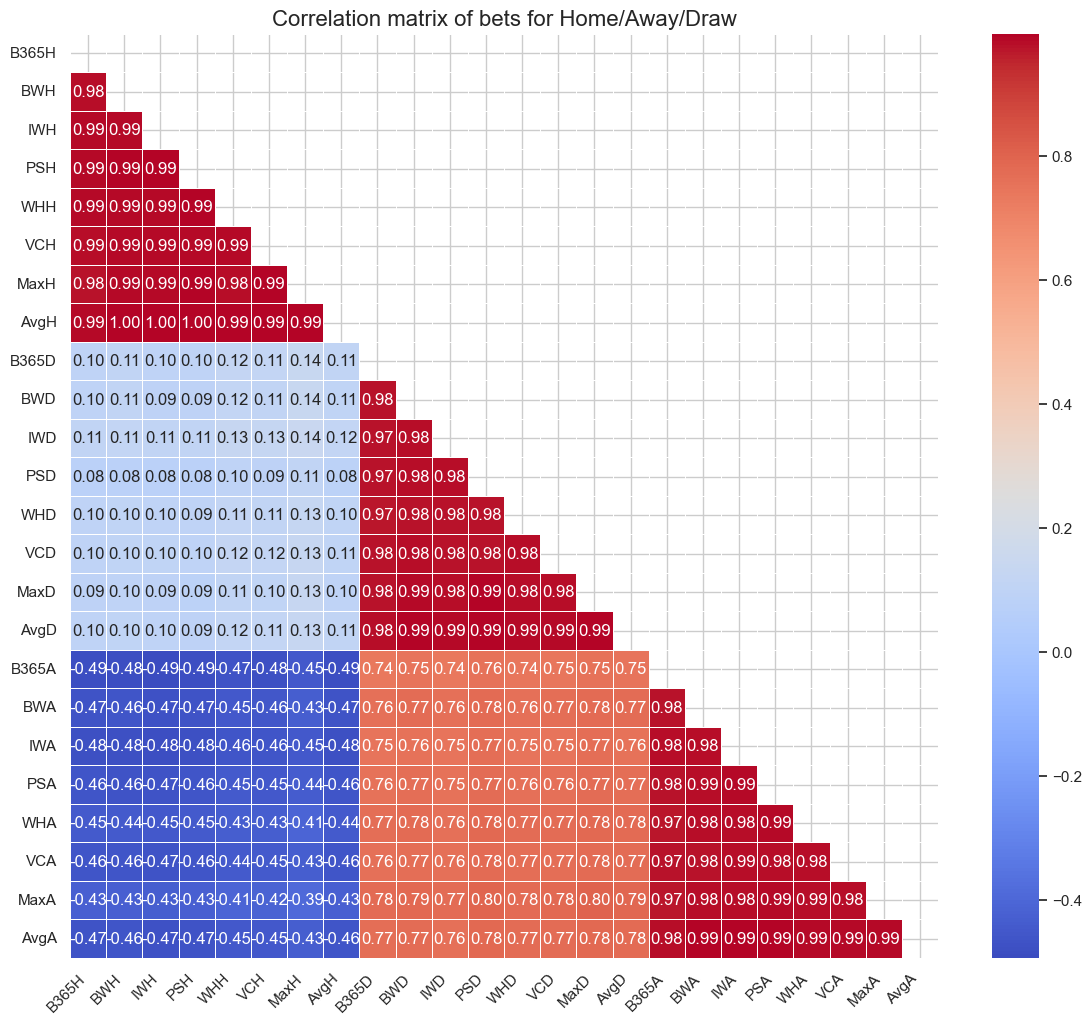

In [86]:
# Pearson correlation matrix of betting odds for Home win/Away win/Draw
cols_to_correlate = ['B365H','BWH','IWH','PSH','WHH','VCH','MaxH','AvgH','B365D','BWD','IWD','PSD','WHD','VCD','MaxD','AvgD','B365A','BWA','IWA','PSA','WHA','VCA','MaxA','AvgA']

correlation_matrix = df[cols_to_correlate].corr()
plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(
    correlation_matrix, 
    mask=mask,
    annot=True,             
    fmt=".2f",            
    cmap='coolwarm',      
    linewidths=.5)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.title('Correlation matrix of bets for Home/Away/Draw', fontsize=16)
plt.show()

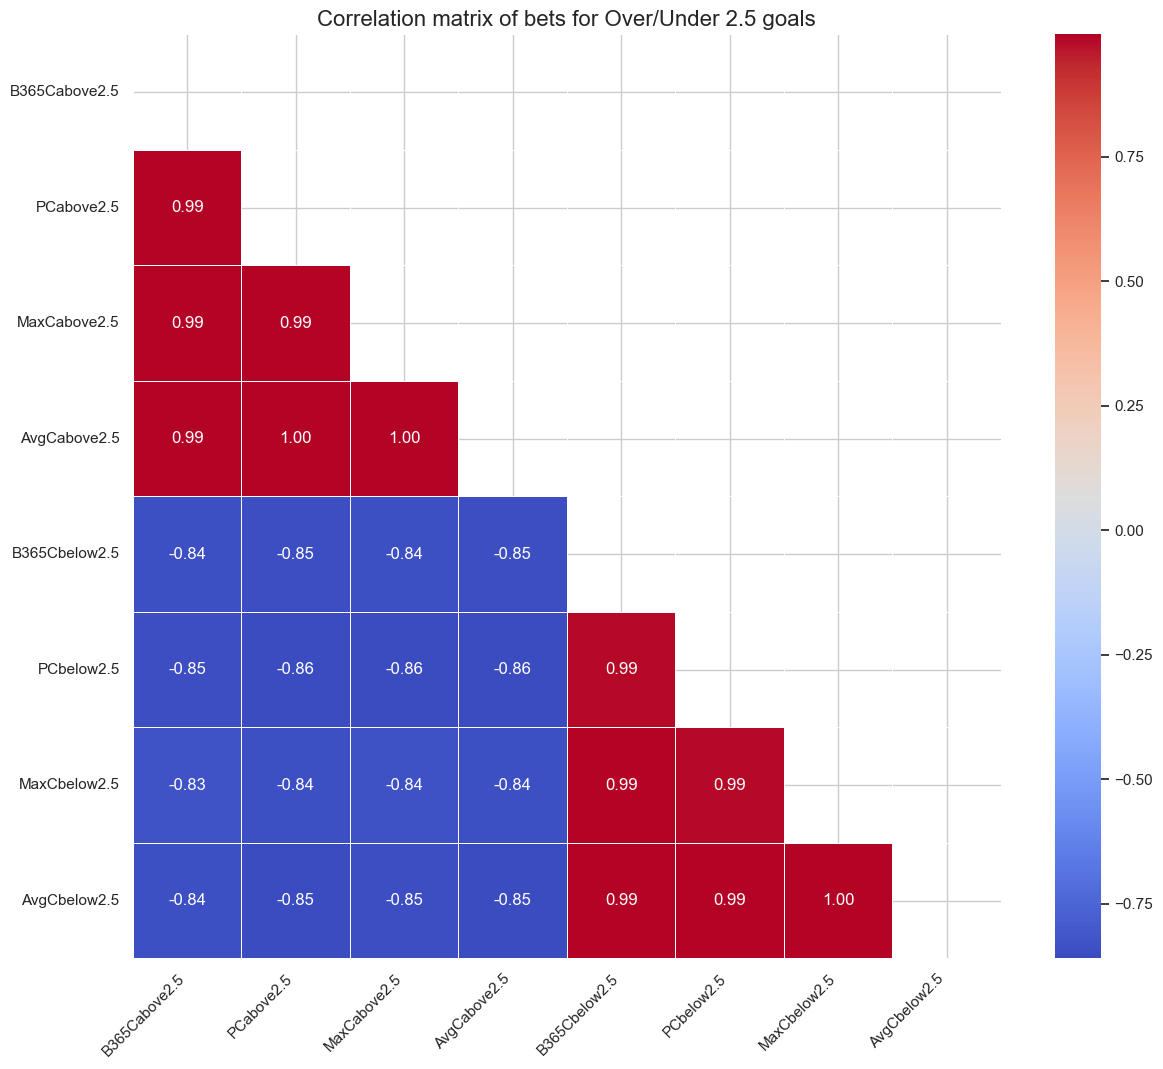

In [87]:
# The same for over/under 2.5 goals
cols_to_correlate = ['B365Cabove2.5','PCabove2.5','MaxCabove2.5','AvgCabove2.5','B365Cbelow2.5','PCbelow2.5','MaxCbelow2.5','AvgCbelow2.5']
correlation_matrix = df[cols_to_correlate].corr()
plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(
    correlation_matrix, 
    mask=mask,
    annot=True,             
    fmt=".2f",            
    cmap='coolwarm',      
    linewidths=.5)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.title('Correlation matrix of bets for Over/Under 2.5 goals', fontsize=16)
plt.show()

Since the correlation across bets is huge, we can only use one of them.

In [88]:
# Deliting unnecessary cols
cols = [
    "Country","League","Period","Div","Date","HomeTeam","AwayTeam","FTHG","FTAG","HS","AS","HST","AST","HF","AF",
    "B365H","B365D","B365A","B365Cabove2.5","B365Cbelow2.5","Referee","Month","IsWeekend","TimeNumeric","DaysFromSeasonStart",
    "DaysSinceLastMatchHome","DaysSinceLastMatchAway","DaysSinceLastMatchDiff","Target","Season","AvgLast8HomeGoalsAgg",
    "AvgLast8AwayGoalsAgg","AvgLast8HomeGoals","AvgLast8AwayGoals","AvgLast8GoalsAgg","AvgLast8Goals"
]
df = df[cols]

In [89]:
df.describe()

,Date,FTHG,FTAG,HS,AS,HST,AST,HF,AF,B365H,B365D,B365A,B365Cabove2.5,B365Cbelow2.5,IsWeekend,TimeNumeric,DaysFromSeasonStart,DaysSinceLastMatchHome,DaysSinceLastMatchAway,DaysSinceLastMatchDiff,Target,AvgLast8HomeGoalsAgg,AvgLast8AwayGoalsAgg,AvgLast8HomeGoals,AvgLast8AwayGoals,AvgLast8GoalsAgg,AvgLast8Goals
count,35464,35464.000000,35464.000000,35424.000000,35424.000000,35424.000000,35424.000000,35422.000000,35422.000000,35347.000000,35347.000000,35347.000000,35400.000000,35400.000000,35464.000000,35464.000000,35464.000000,35464.000000,35464.000000,35464.000000,35464.000000,35443.000000,35443.000000,35443.000000,35443.000000,35443.000000,35443.000000
mean,2022-01-20 14:35:01.691856384,1.465486,1.197581,12.867293,10.875339,4.575796,3.848747,12.360793,12.576365,2.627595,3.761136,3.953814,1.975071,1.953948,0.713851,16.505433,161.874323,11.703220,11.686809,2.181705,0.498477,1.318373,1.336027,1.462943,1.193292,2.654400,2.656236
min,2019-07-26 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.910000,1.050000,0.000000,0.000000,0.000000,10.500000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2020-12-12 00:00:00,1.000000,0.000000,9.000000,8.000000,3.000000,2.000000,9.000000,10.000000,1.800000,3.300000,2.450000,1.700000,1.660000,0.000000,15.000000,89.000000,4.000000,4.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.875000,2.125000,2.125000
50%,2022-01-22 00:00:00,1.000000,1.000000,12.000000,10.000000,4.000000,4.000000,12.000000,12.000000,2.250000,3.500000,3.200000,1.950000,1.880000,1.000000,15.750000,164.000000,7.000000,7.000000,0.000000,0.000000,1.250000,1.250000,1.375000,1.125000,2.625000,2.625000
75%,2023-04-01 00:00:00,2.000000,2.000000,16.000000,14.000000,6.000000,5.000000,15.000000,15.000000,2.880000,3.800000,4.500000,2.200000,2.100000,1.000000,19.000000,229.000000,8.000000,8.000000,1.000000,1.000000,1.625000,1.625000,1.750000,1.500000,3.125000,3.125000
max,2024-06-02 00:00:00,9.000000,13.000000,46.000000,45.000000,23.000000,23.000000,40.000000,77.000000,34.000000,17.000000,41.000000,4.330000,7.000000,1.000000,22.000000,364.000000,1126.000000,832.000000,1064.000000,1.000000,6.000000,7.000000,7.000000,5.000000,8.000000,11.000000
std,NaN,1.257095,1.140480,5.143507,4.658151,2.499473,2.274165,4.108310,4.136777,1.555609,0.986010,2.763479,0.368631,0.446697,0.451966,2.543071,86.928087,33.841882,33.196063,18.931947,0.500005,0.552253,0.558198,0.609823,0.525496,0.813905,0.830003


In [90]:
# checks which teams played in more than one league - which could indicate better/worse performance due to league changes
df_home = df[['Country', 'Div', 'HomeTeam']].rename(columns={'HomeTeam': 'Team'})
df_away = df[['Country', 'Div', 'AwayTeam']].rename(columns={'AwayTeam': 'Team'})
all_matches_long = pd.concat([df_home, df_away])
unique_team_leagues = all_matches_long.drop_duplicates()

migration_summary = unique_team_leagues.groupby('Team').agg(
    Leagues_Played=('Div', lambda x: ', '.join(x.unique())), 
    League_Count=('Div', 'nunique') 
).reset_index()

migrating_teams = migration_summary[migration_summary['League_Count'] > 1]
migrating_teams = migrating_teams.sort_values(by='League_Count', ascending=False)
final_table = migrating_teams[['Team', 'Leagues_Played']] 

display(final_table)

,Team,Leagues_Played
193,hamilton,"SC0, SC1, SC2"
111,cove rangers,"SC1, SC2, SC3"
341,queens park,"SC1, SC2, SC3"
330,plymouth,"E1, E2, E3"
4,afc wimbledon,"E2, E3"
...,...,...
445,watford,"E0, E1"
447,werder bremen,"D1, D2"
448,west brom,"E0, E1"
451,wigan,"E1, E2"


##### Distributions and 1D outliers in all valid numeric columns:

26 numeric cols found


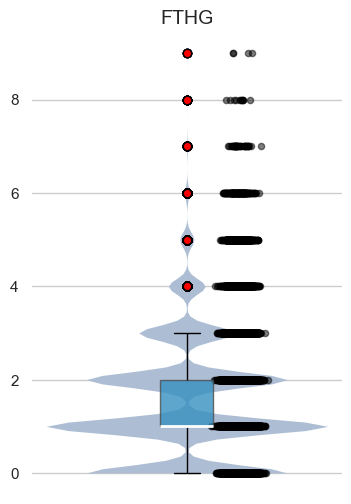

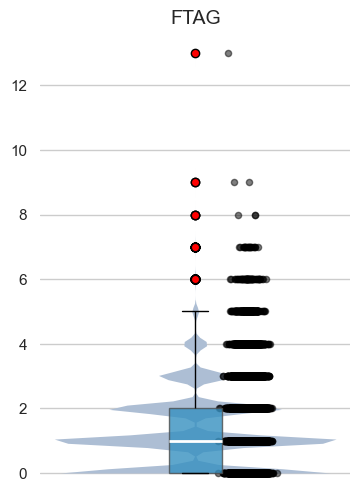

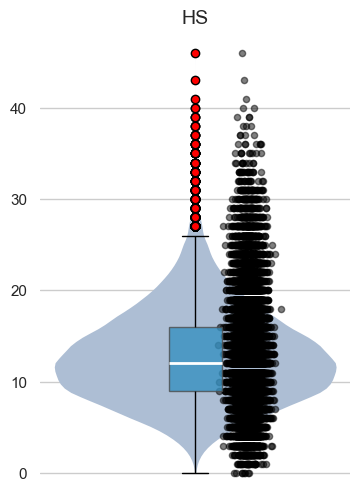

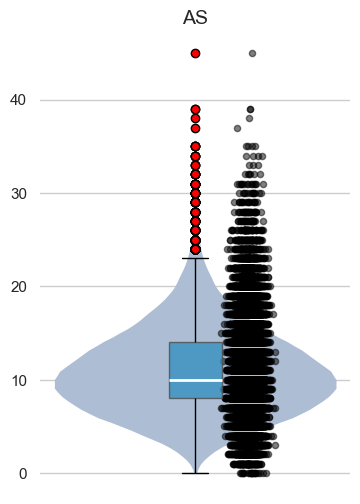

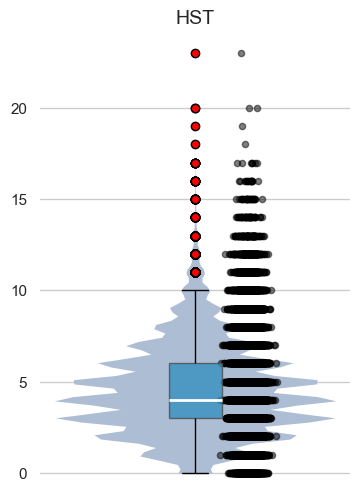

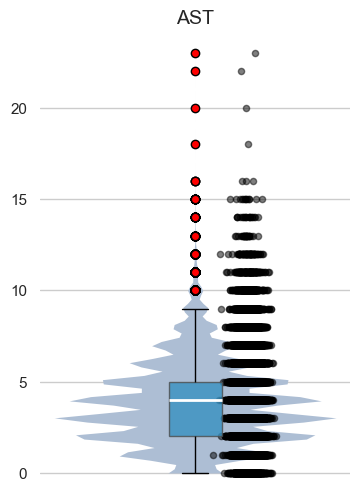

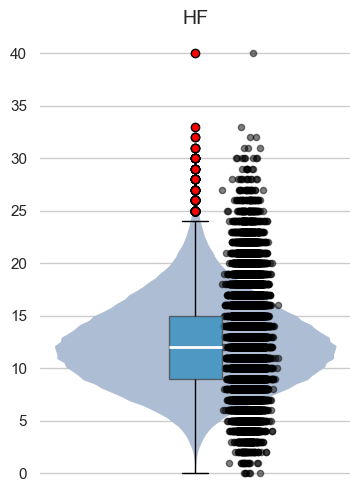

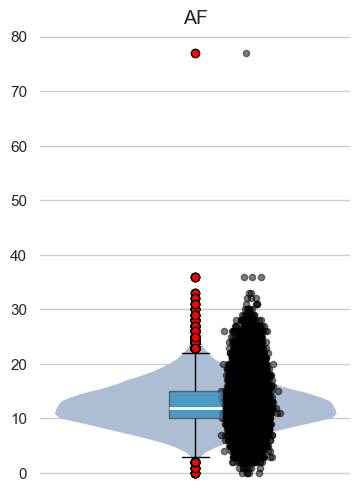

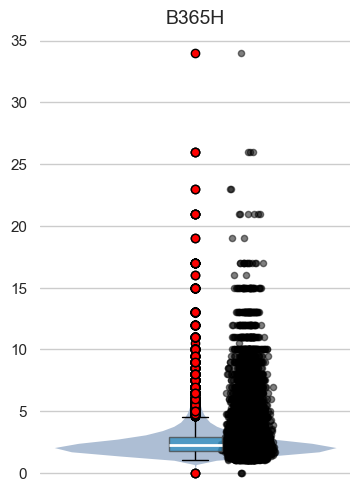

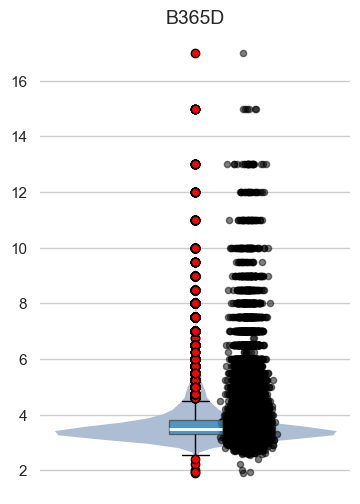

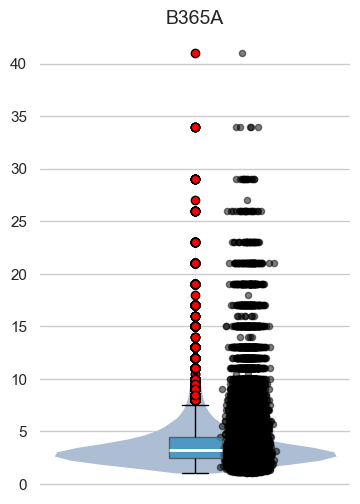

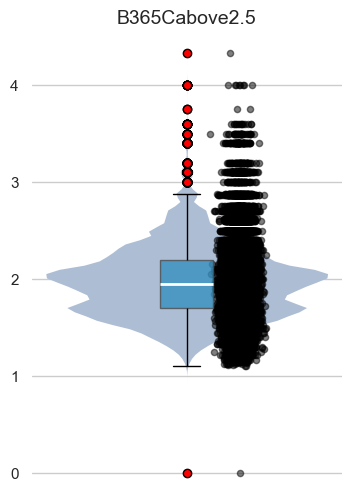

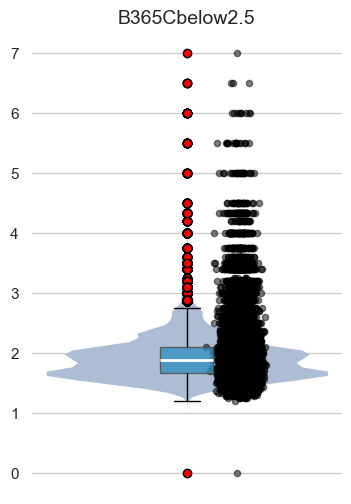

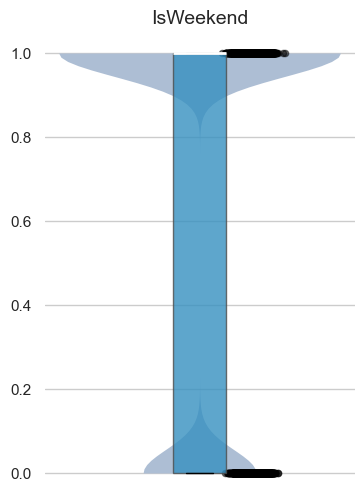

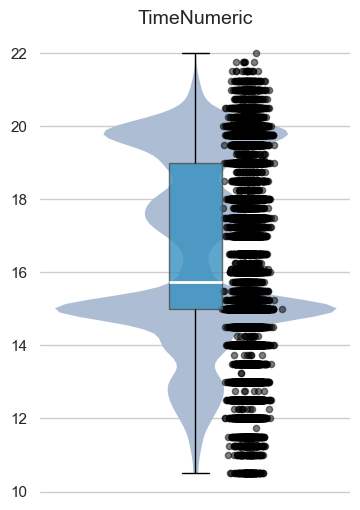

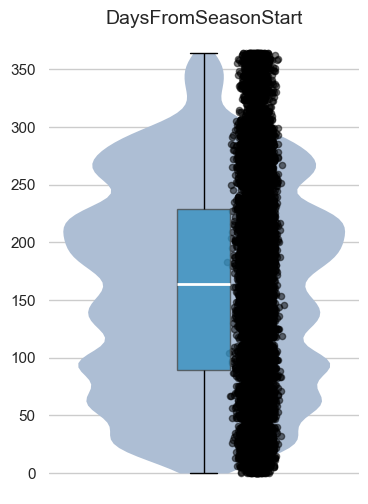

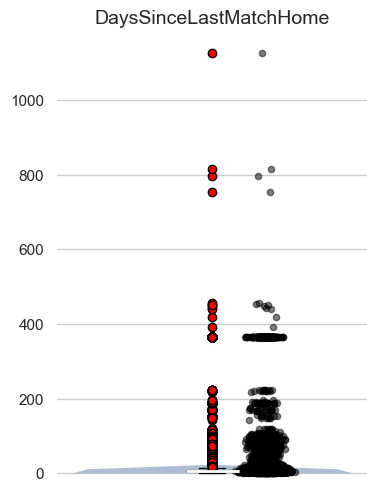

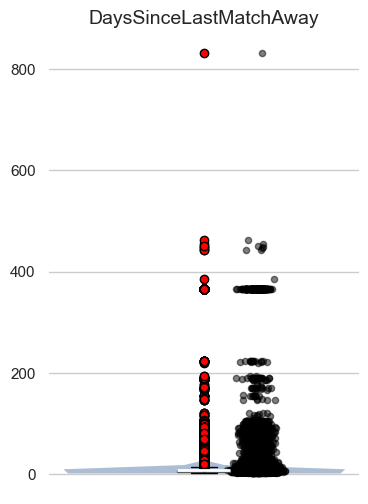

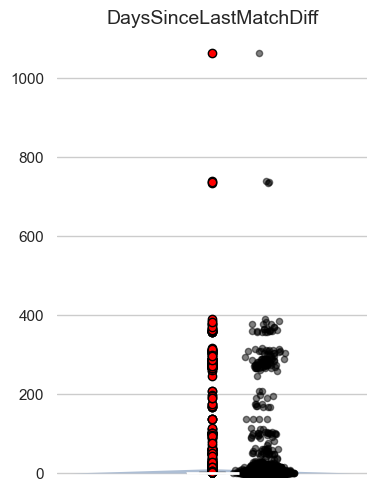

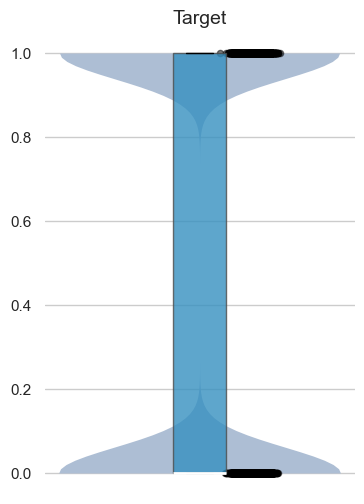

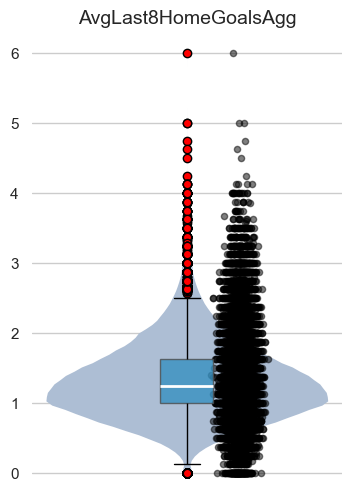

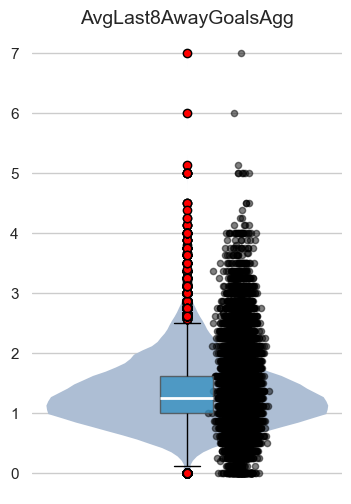

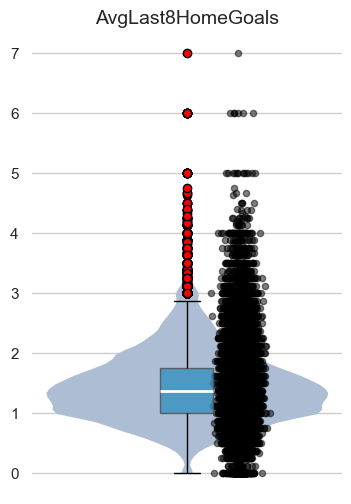

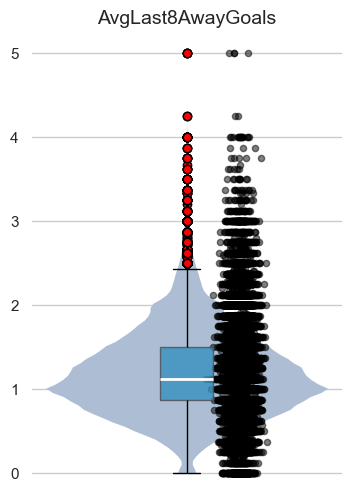

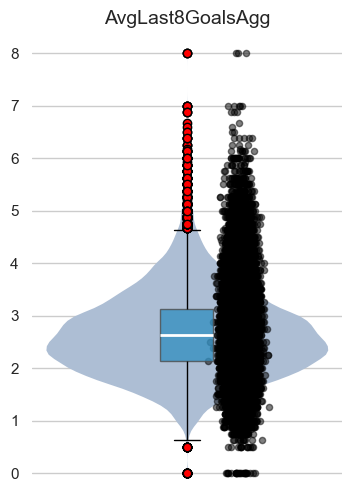

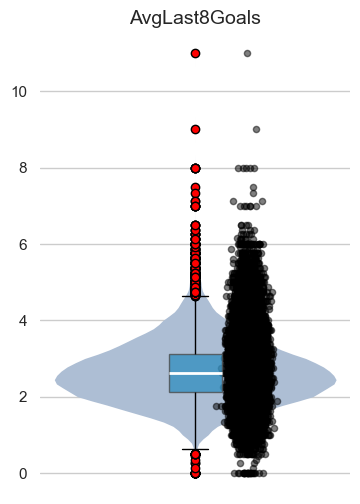

In [91]:
# sth like raincloud plot for all numeric columns
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
print(f"{len(numeric_cols)} numeric cols found")

for col in numeric_cols:
    data = df[col].copy()
    data = data.dropna()
    
    if data.empty or len(data) < 2:
        print(f"Warning: Column '{col}' was empty after dropping NaNs or has insufficient data.")
        continue

    sns.set(style="whitegrid")
    fig, ax = plt.subplots(figsize=(4, 6))

    sns.violinplot( # adding violin plot
        y=data,
        inner=None,
        color="#a6bddb",
        linewidth=0,
        width=0.8,
        cut=0,
        ax=ax)
    sns.boxplot( # adding boxplot
        y=data,
        width=0.15,
        boxprops={"facecolor": "#3690c0", "alpha": 0.8},
        medianprops={"color": "white", "linewidth": 2},
        whiskerprops={"color": "black"},
        capprops={"color": "black"},
        showfliers=True,
        flierprops={"marker": "o", "markersize": 6, "markerfacecolor": "red", "markeredgecolor": "black"},
        ax=ax)
    x_offset = 0.15 # adding jitter
    ax.scatter(
        np.random.normal(loc=x_offset, scale=0.02, size=len(data)),
        data,
        alpha=0.5,
        s=20,
        color="black")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title(col, fontsize=14)
    sns.despine(left=True, bottom=True)
    plt.show()

# I would like to take this space to thank God on behalf of Sam Altman (and his gang) (amen) (╯˘ -˘ )╯

The dataset does not appear to contain any outliers that would be impossible in reality.

The DaysSinceLastMatch columns obviously contain extreme values (300/500+ days), which are not errors, but reflect teams absent from recorded leagues (e.g. due to relegation/promotion gaps). These columns could signal zero recent form, that's why we'll keep them in our dataset.

In [92]:
# Although 36 fouls for one team (in total 47 per 90 minutes) sounds like a Colosseum-worthy experience.
# (... btw Greek 1st division, so i wouldn't be surprised)
# (... btw that team won :) )
# df = df.drop(df["AF"].idxmax())

##### Linearity and 2D outliers:

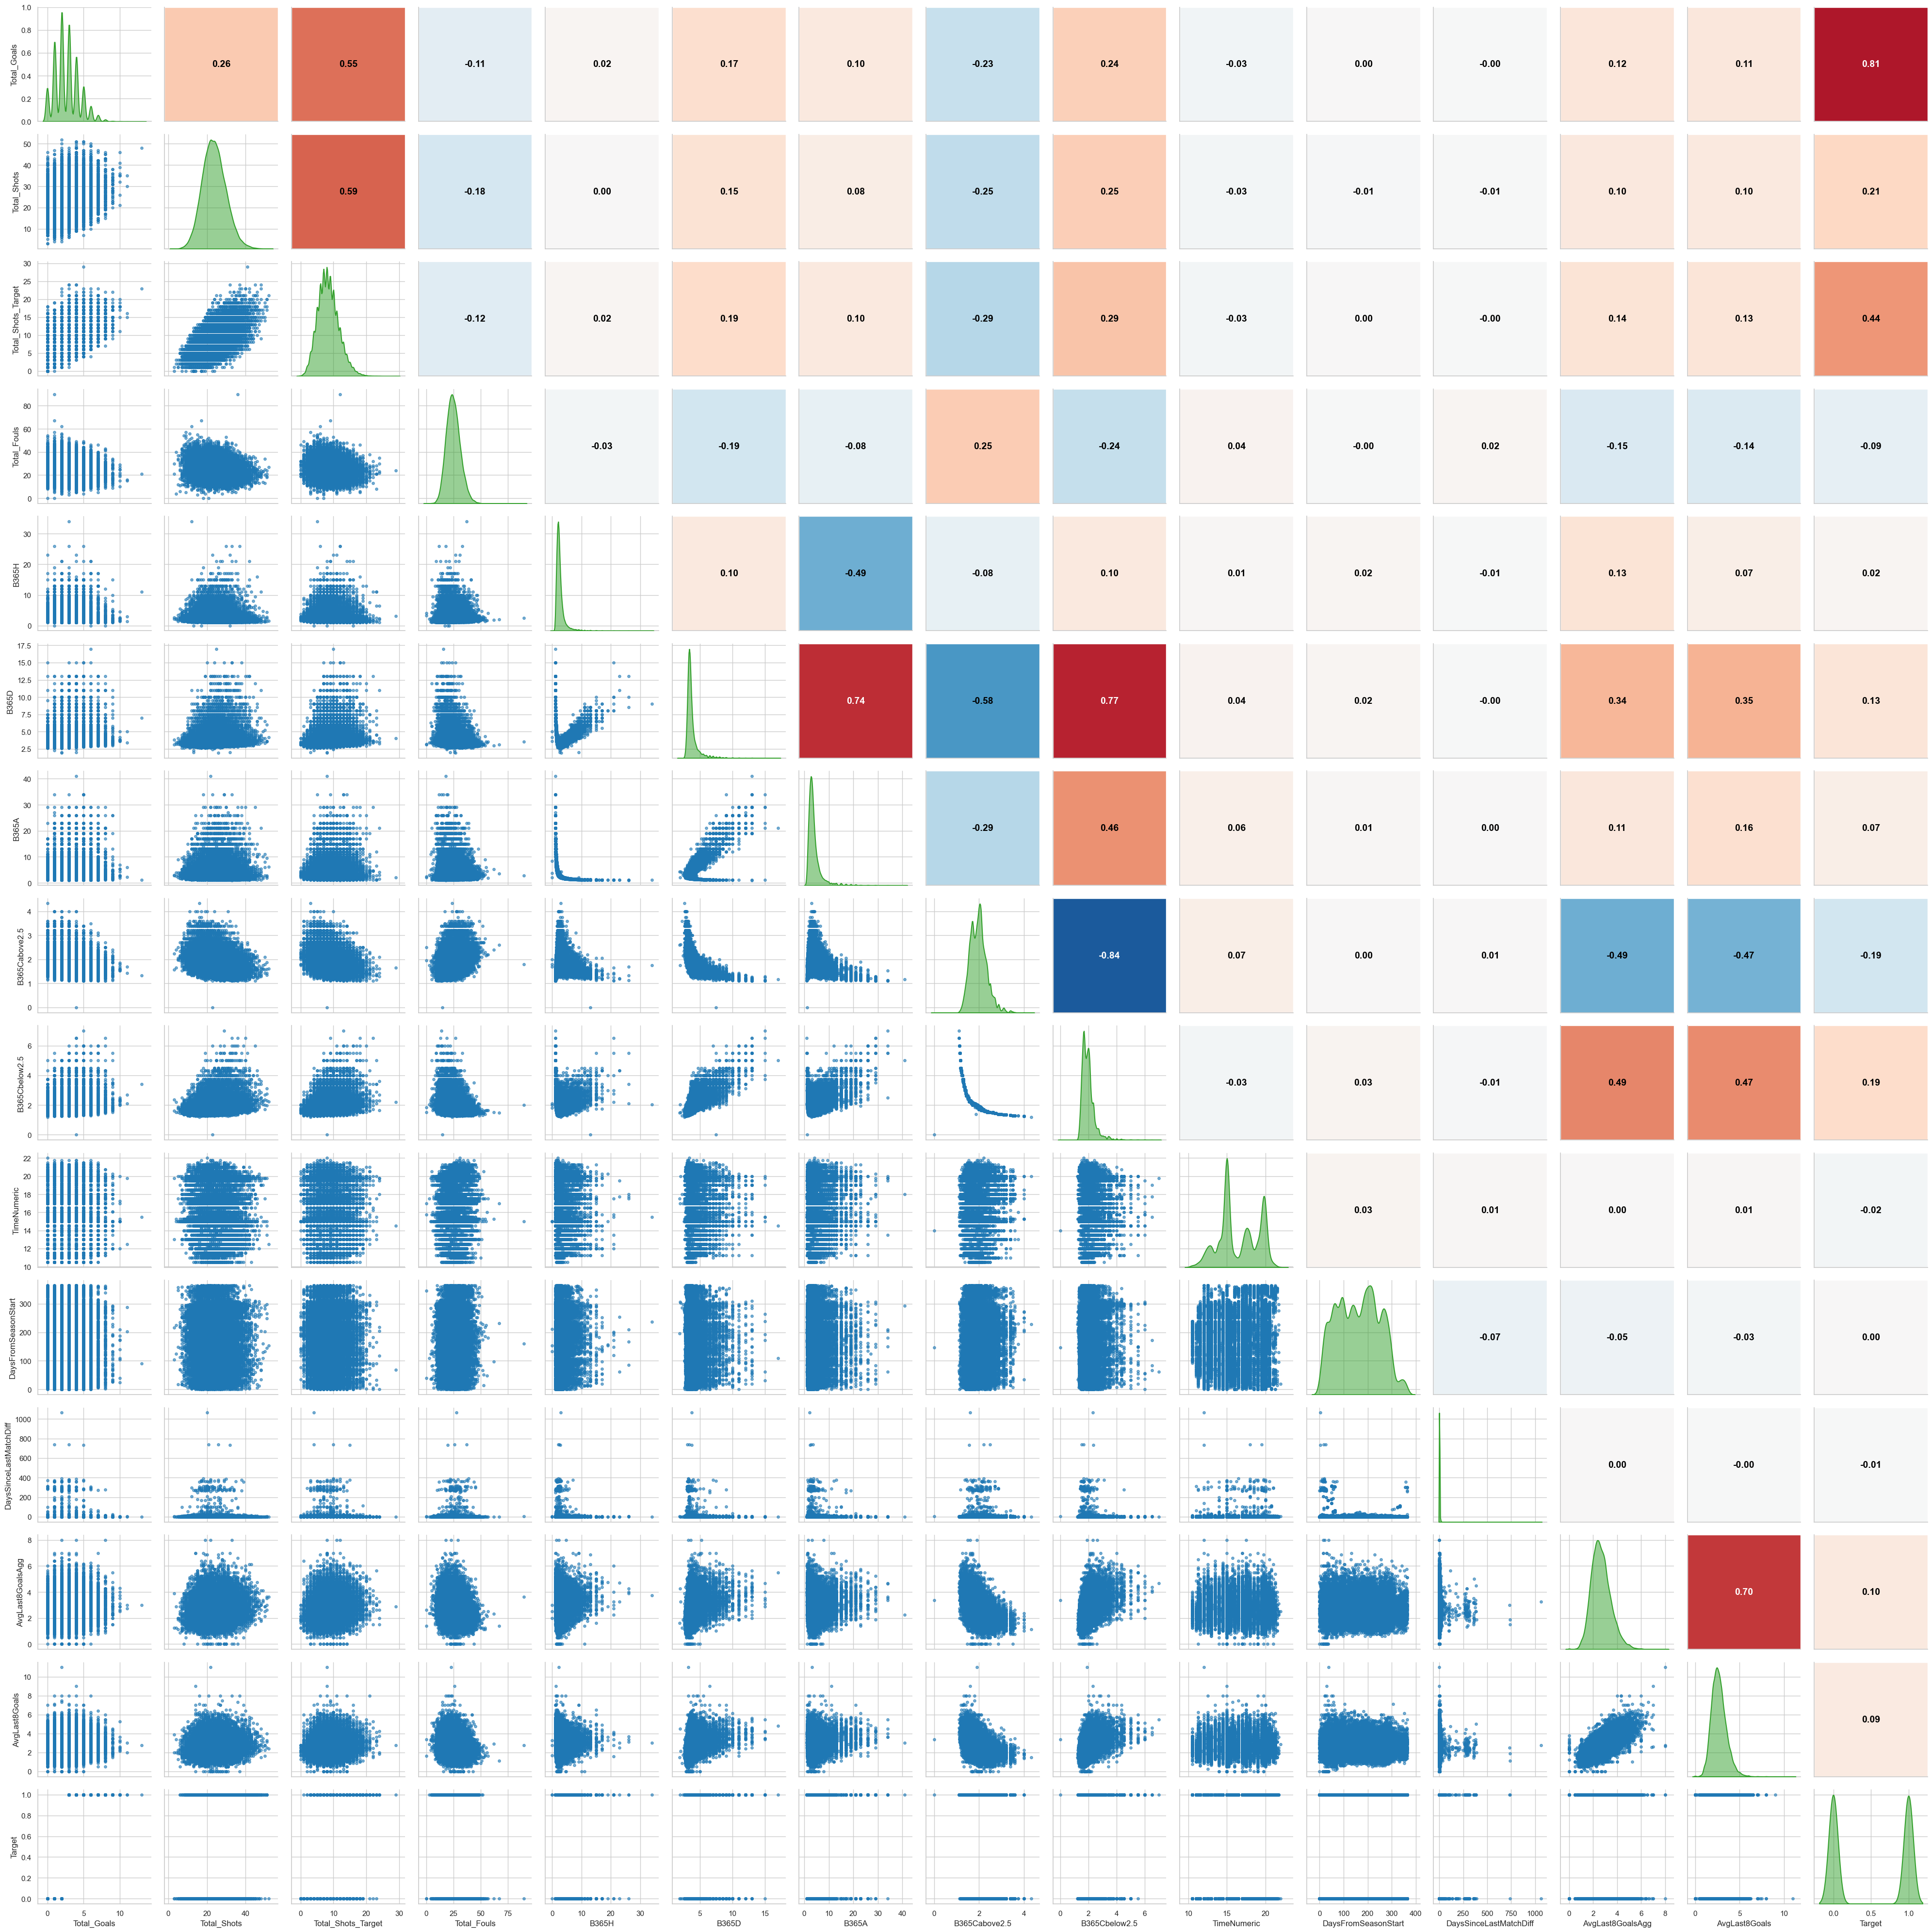

In [93]:
# pairwise plots + correlation heatmap + distributions on diagonal
aggregation_pairs = {
    'Total_Goals': ('FTHG', 'FTAG'),      
    'Total_Shots': ('HS', 'AS'),           
    'Total_Shots_Target': ('HST', 'AST'),  
    'Total_Fouls': ('HF', 'AF'),
    }

for new_col, (home_col, away_col) in aggregation_pairs.items():
    if home_col in df.columns and away_col in df.columns:
        df[new_col] = df[home_col] + df[away_col]
        
def corr_heatmap_func(x, y, **kwargs):
    r = x.corr(y)
    cmap = plt.cm.get_cmap('RdBu_r') 
    norm = plt.Normalize(-1, 1) 
    ax = plt.gca()
    ax.add_patch(plt.Rectangle((0, 0), 1, 1,
                               transform=ax.transAxes,
                               facecolor=cmap(norm(r)),
                               alpha=1.0, 
                               zorder=1,
                               clip_on=False))
    
    text_color = 'black' if abs(r) < 0.6 else 'white' 
    ax.text(0.5, 0.5, f"{r:.2f}",
            horizontalalignment='center', verticalalignment='center',
            fontsize=14, color=text_color, weight='bold', transform=ax.transAxes)

def scatter_func(x, y, **kwargs):
    plt.scatter(x, y, alpha=0.6, s=15, color='#1f78b4')
    
def kde_func(x, **kwargs):
    sns.kdeplot(x, fill=True, color='#33a02c', alpha=0.5, linewidth=1.5)

selected_cols = ['Total_Goals', 'Total_Shots', 'Total_Shots_Target', 'Total_Fouls','B365H', 'B365D', 'B365A', 'B365Cabove2.5', 'B365Cbelow2.5', 'TimeNumeric', 'DaysFromSeasonStart','DaysSinceLastMatchDiff', 'Season', 'AvgLast8GoalsAgg', 'AvgLast8Goals', 'LastMatchGoals', 'AttackDiff', 'DefenseDiff', 'OverRateDiff','Target']
plot_cols = [col for col in selected_cols if col in df.columns and pd.api.types.is_numeric_dtype(df[col])]

g = sns.PairGrid(df.dropna(subset=plot_cols), vars=plot_cols, diag_sharey=False)
g.map_diag(kde_func)
g.map_upper(corr_heatmap_func)
g.map_lower(scatter_func)
g.fig.set_size_inches(40, 40) 

plt.tight_layout()
plt.show()

# Sorry for the readibility, but it's better than having it in multiple various charts :).

There doesn't appear to be any extreme unrealistic 2D outlier in the dataset (and if so, it is with betting odds, where it's more likely that the company was mistaken in its prediction).

Clear relationships can only be seen in directly related variables. In other cases, greater visibility of dependence is associated with greater variability, and such relationships are never purely linear.

Plus, it's nice to see how the opposite betting odds go against each other.

##### Searching for XD outliers (meaning more-dimensional outliers):

Rows for PCA: 35288
Variance captured PC1: 19.62%
Variance captured PC2: 12.39%
Total variance captured by PC1 and PC2: 32.01%


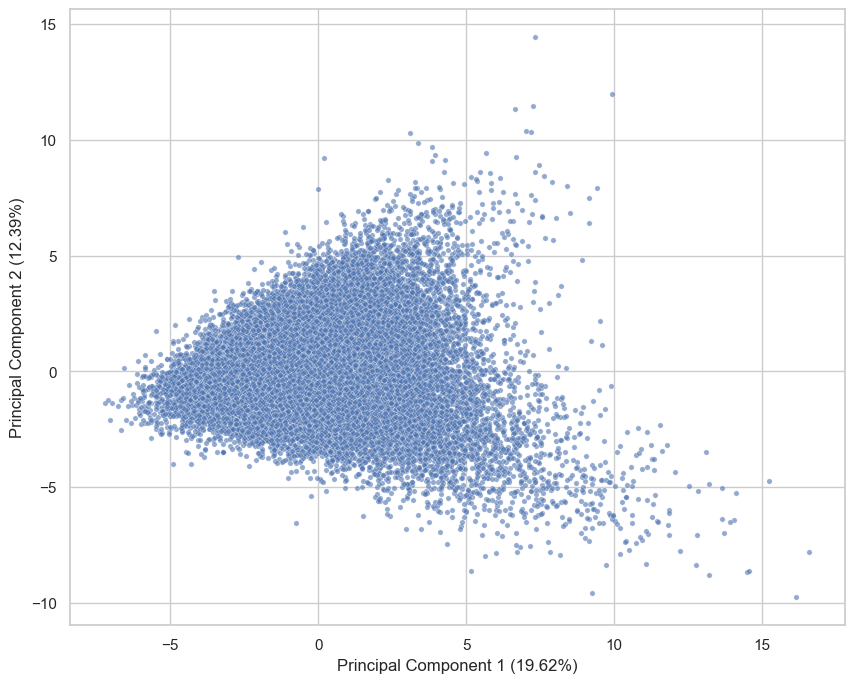

In [94]:
# trying to create PCA in order to find multi-dimensional outliers in the dataset
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

if 'LastMatchGoals' in numeric_cols:
    numeric_cols.remove('LastMatchGoals') # dropping 1 col with most NAs
    
df_pca = df[numeric_cols].dropna().copy()
print(f"Rows for PCA: {len(df_pca)}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_pca)

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(data = principal_components, 
                      columns = ['Principal Component 1', 'Principal Component 2'],
                      index=df_pca.index) 

print(f"Variance captured PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"Variance captured PC2: {pca.explained_variance_ratio_[1]:.2%}")
print(f"Total variance captured by PC1 and PC2: {pca.explained_variance_ratio_.sum():.2%}")

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='Principal Component 1', 
    y='Principal Component 2', 
    data=pca_df, 
    alpha=0.6, 
    s=15
)
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]:.2%})')
plt.show()

Although the scatterplot shows a cluster with some single points sticking out (possible outliers), we can't be sure if they are real anomalies or just valid, rare observations projected into a plane with low information content – 68.99 % of the data variance is not captured (so we cannot rely much on this 2D projection). For this reason, we keep these possible outliers in the dataset.

##### Feature importances:

In [95]:
# proportion of target variable values
df["Target"].value_counts(normalize=True)

# looks well balanced

Target
0    0.501523
1    0.498477
Name: proportion, dtype: float64

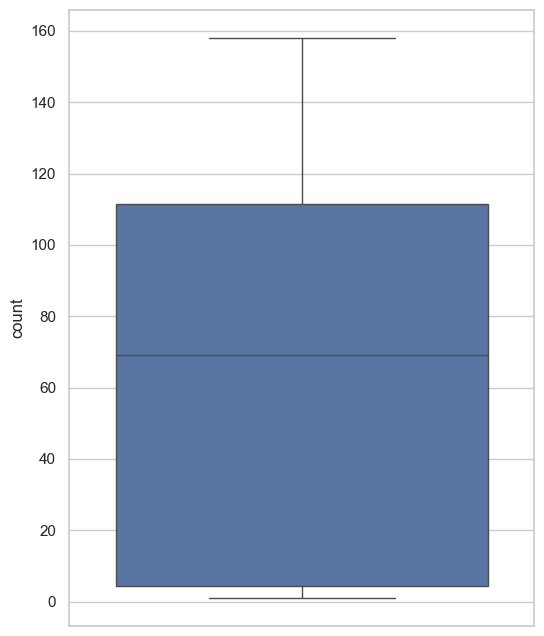

In [96]:
### info about referees
# we have this column only for England and Scotland - in total 8/21 divisions


# distribution of matches count per referee

referees = df['Referee'].astype(str).str.lower().str.strip()
nan = ['']
df_filtered = df[~referees.isin(nan)].copy()
referee_counts = df_filtered['Referee'].value_counts()

plt.figure(figsize=(6, 8))
sns.boxplot(y=referee_counts)
plt.xticks([]) 
plt.show()

# most of the referees should have significantly enough matches to compute another meaningful measures

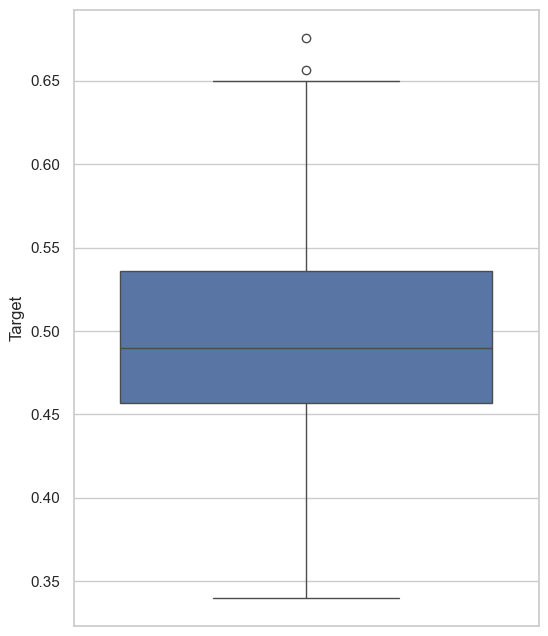

In [97]:
# distribution of average target value per referee (if more than 30 matches)
referees_series = df['Referee'].astype(str).str.lower().str.strip()
df_filtered = df[~referees_series.isin(nan)].copy()
referee_target_mean = (df_filtered[df_filtered['Referee'].isin(referee_counts[referee_counts > 30].index)].groupby('Referee')['Target'].mean()) # (❁´◡`❁)

plt.figure(figsize=(6, 8))
sns.boxplot(y=referee_target_mean)
plt.xticks([]) 
plt.show()

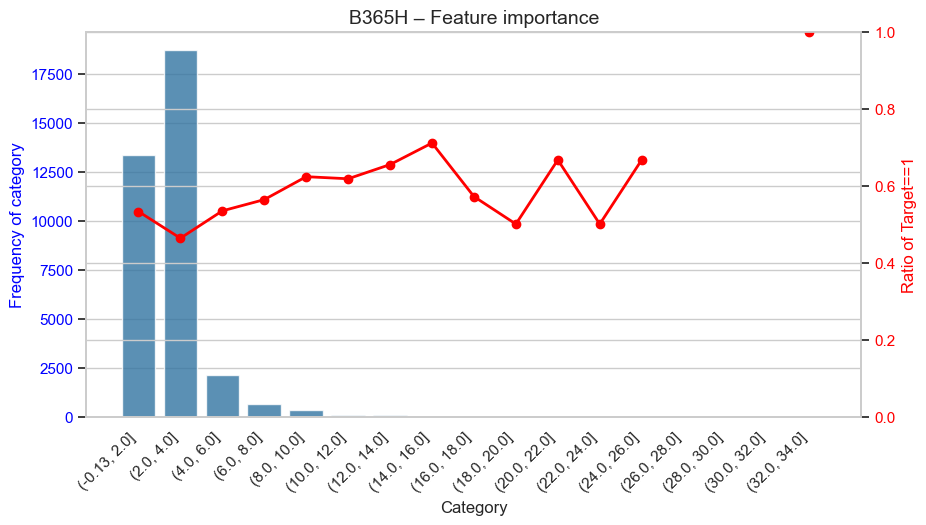

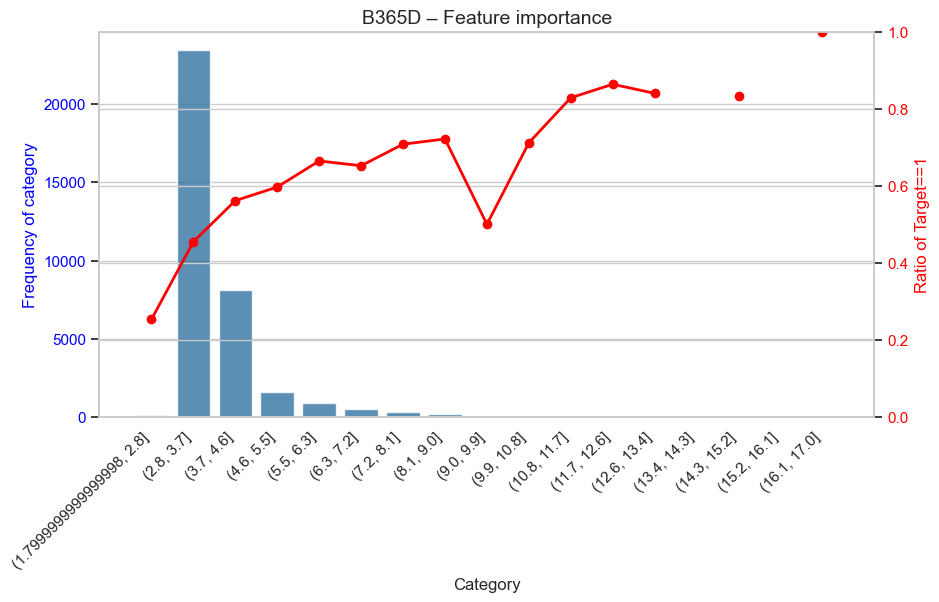

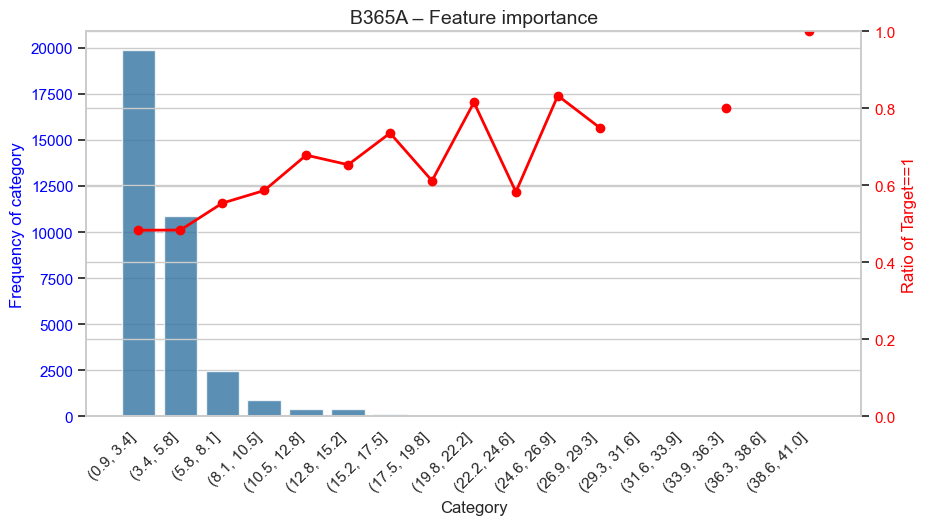

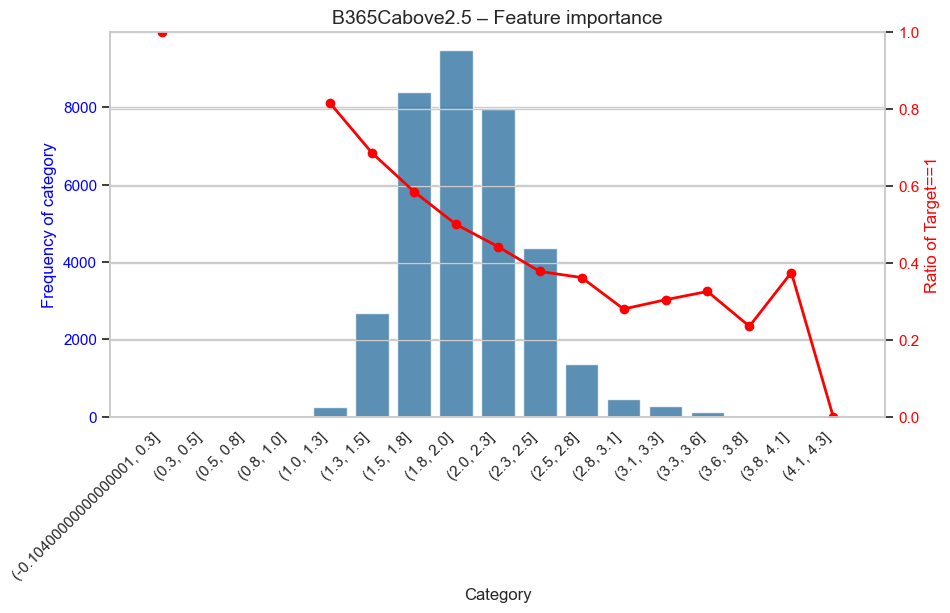

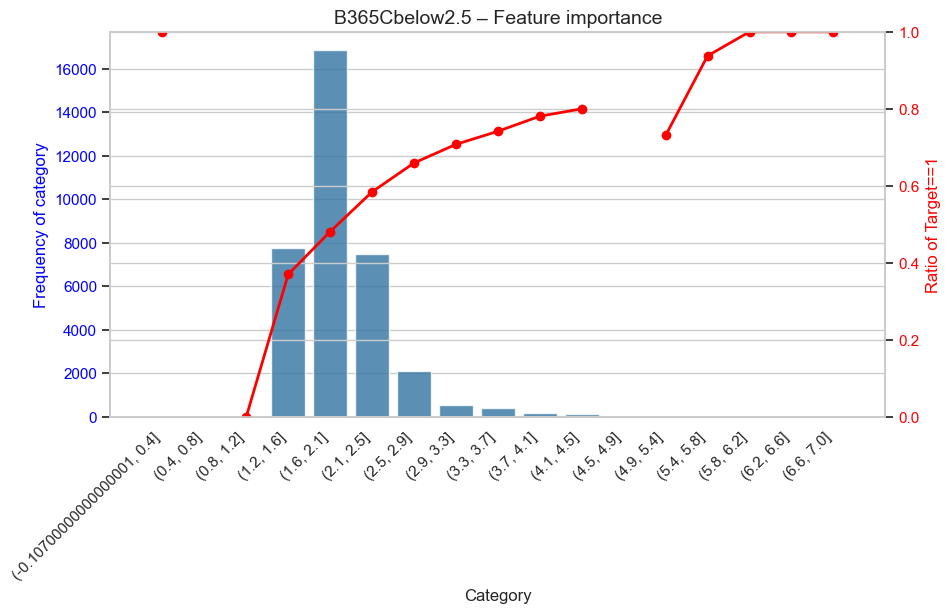

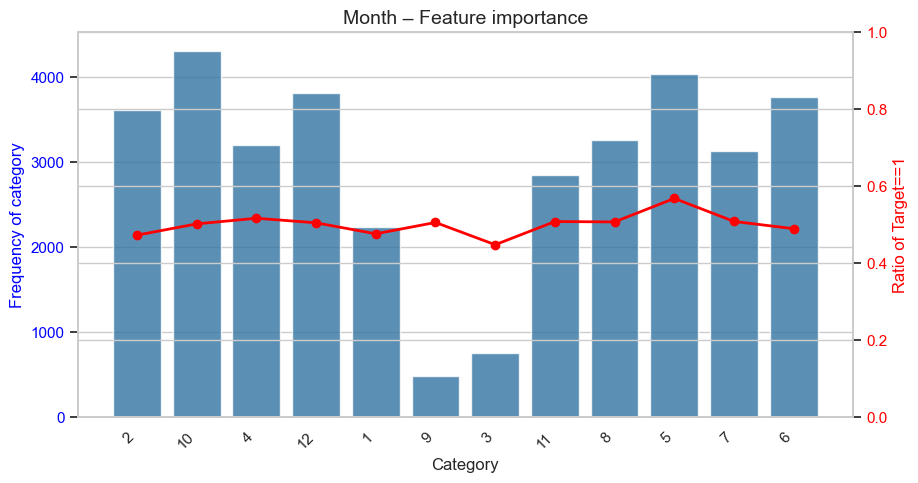

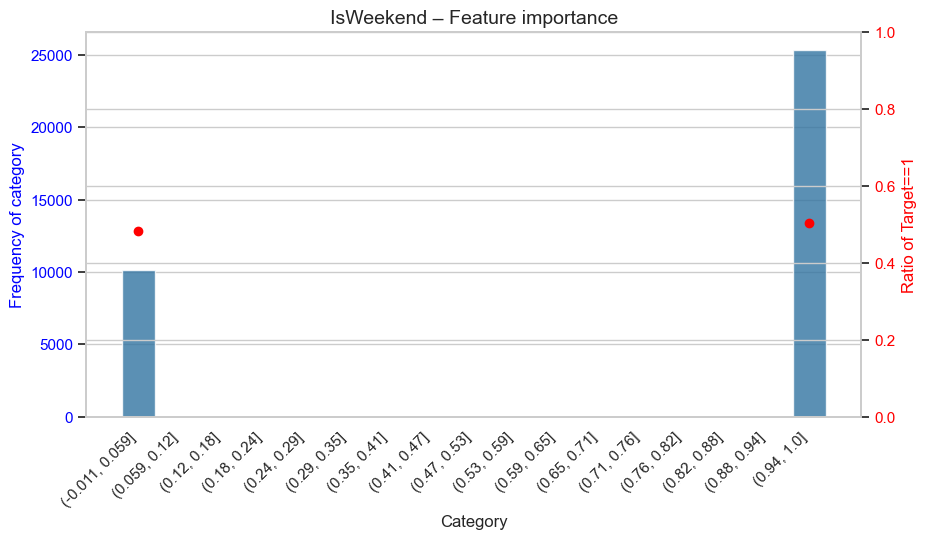

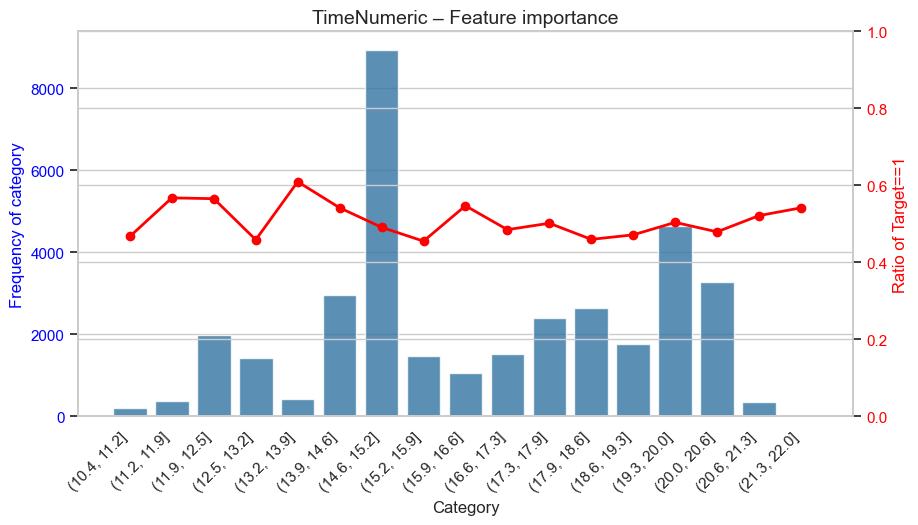

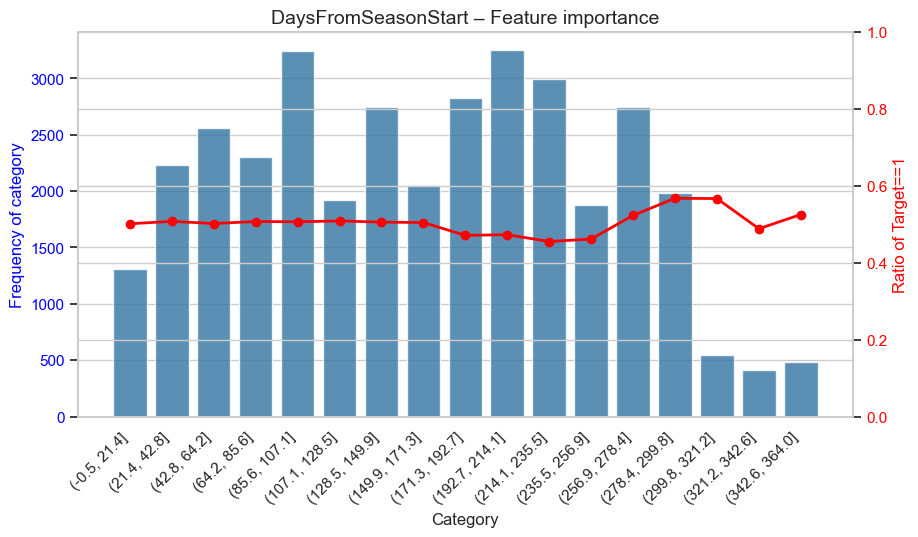

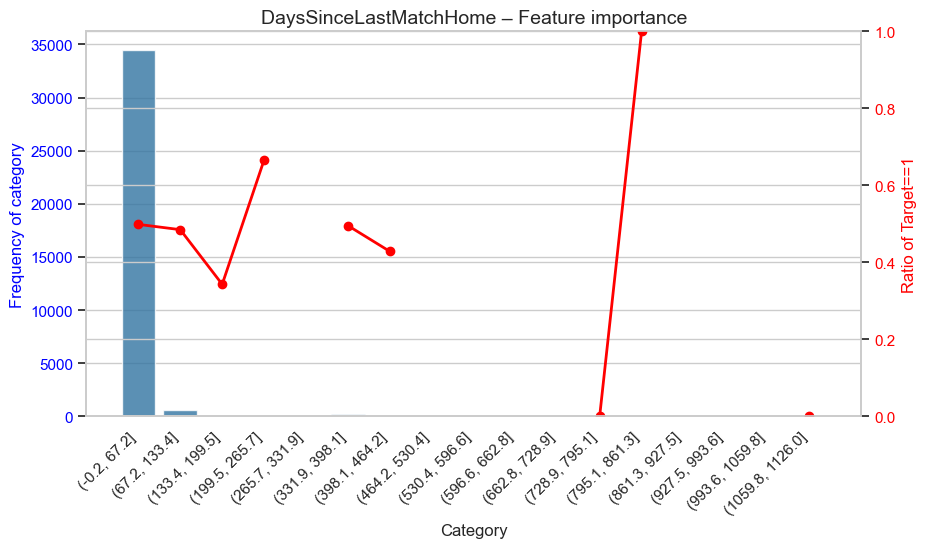

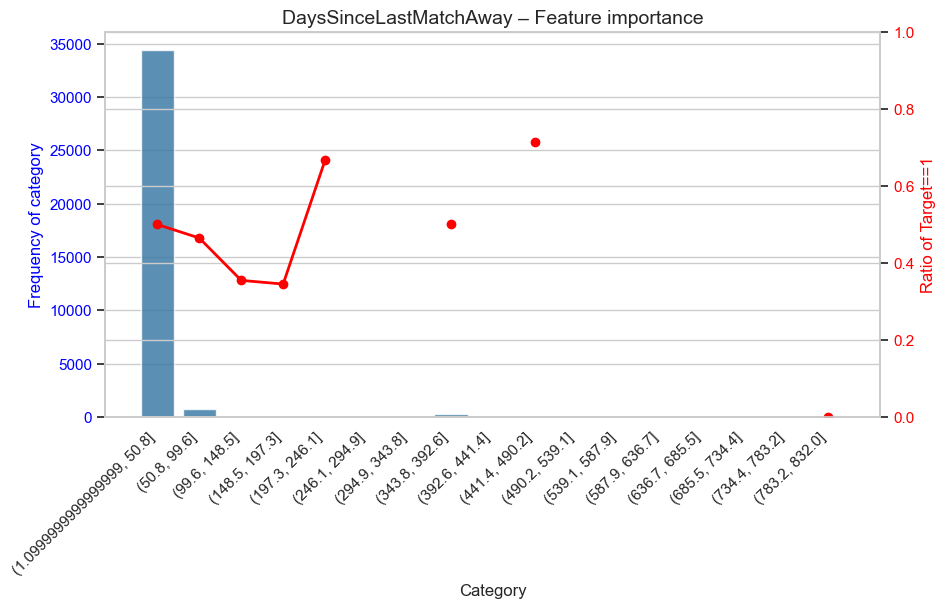

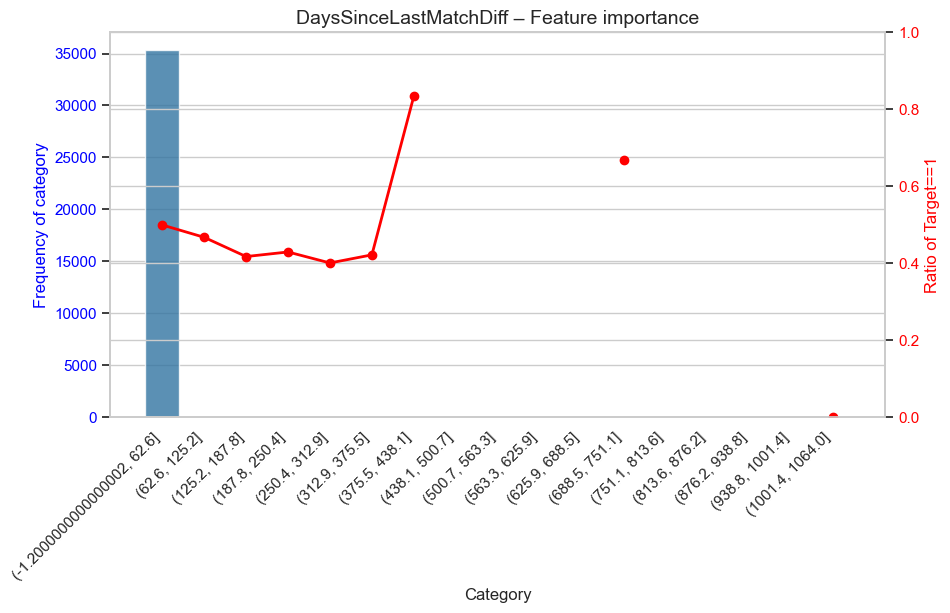

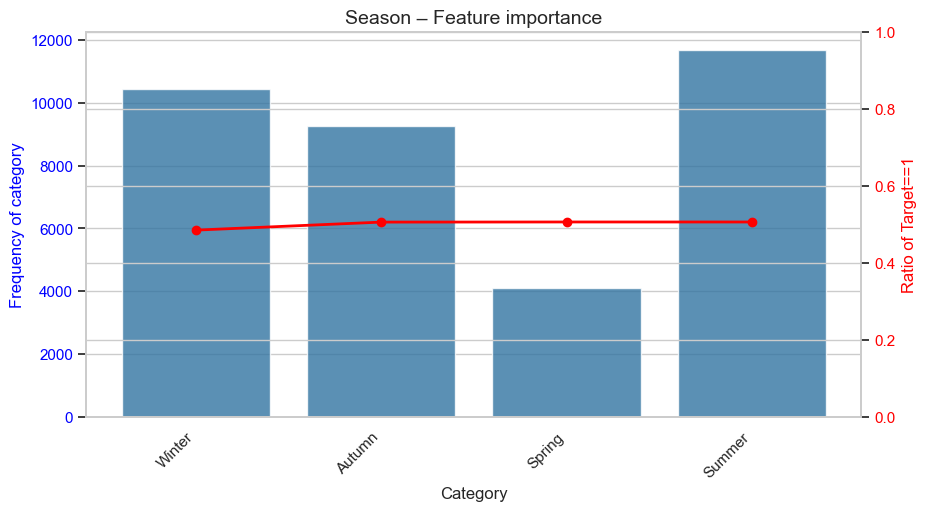

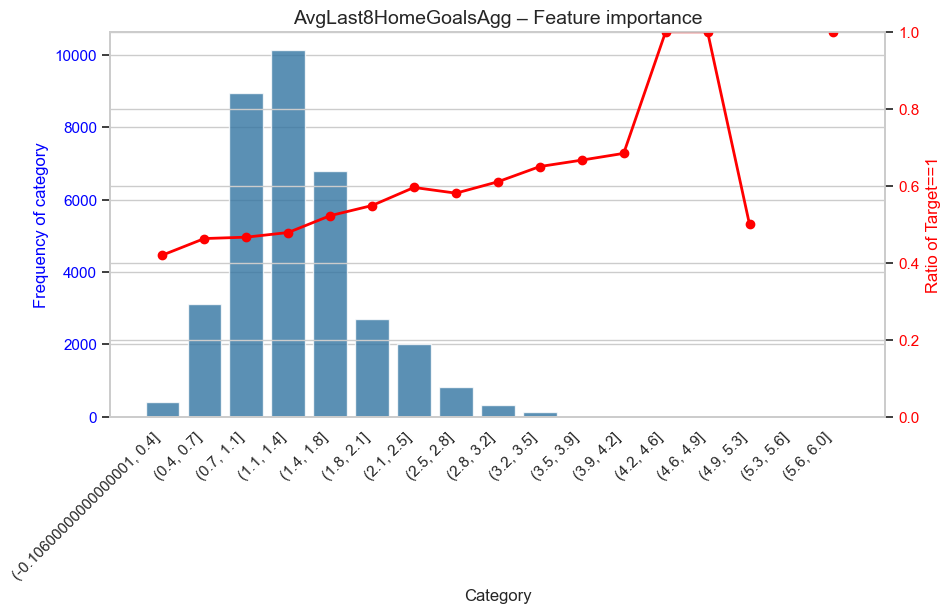

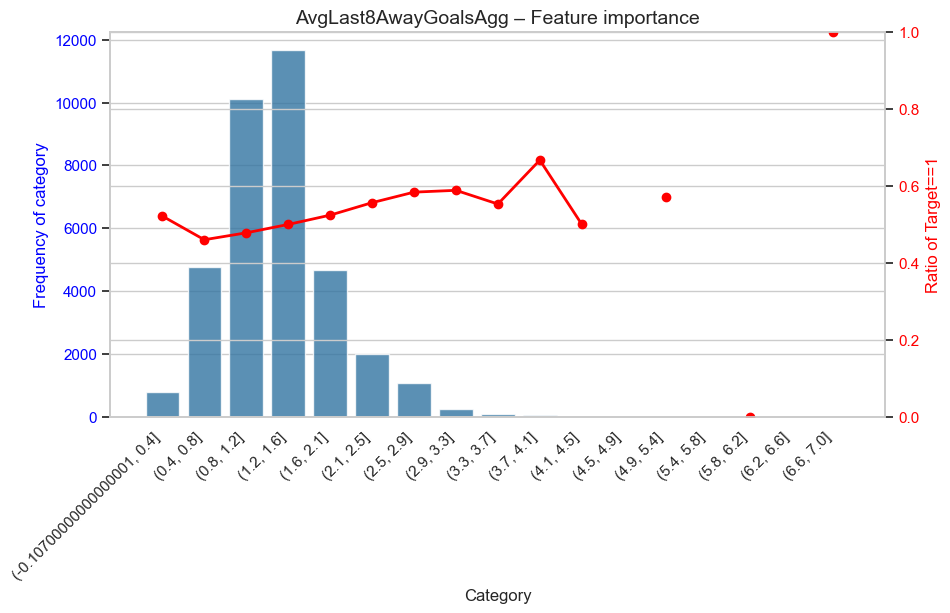

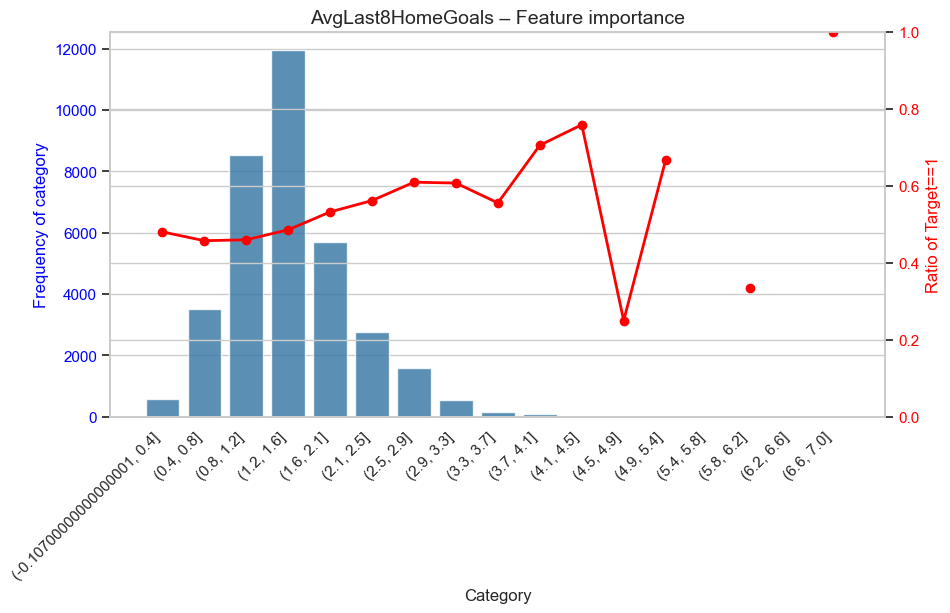

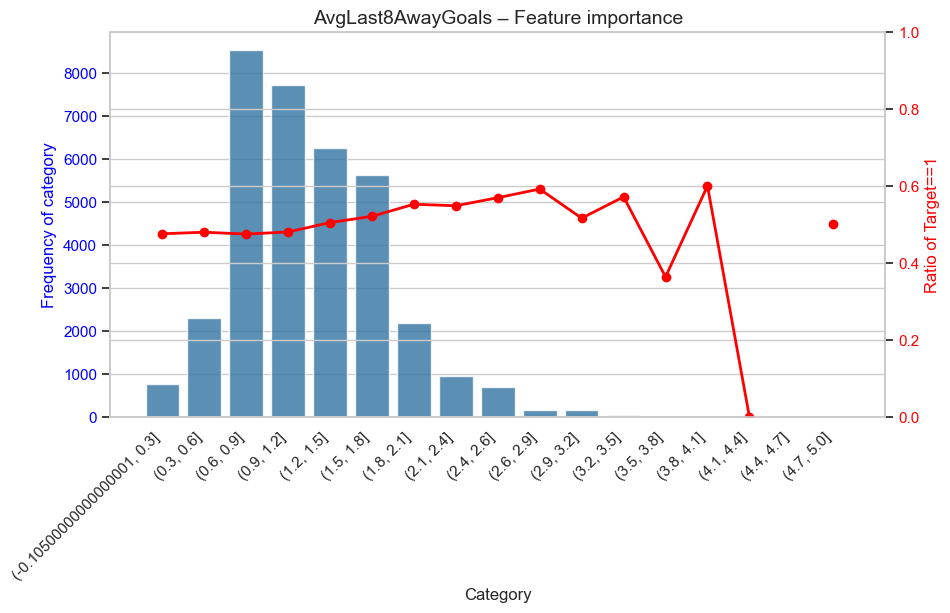

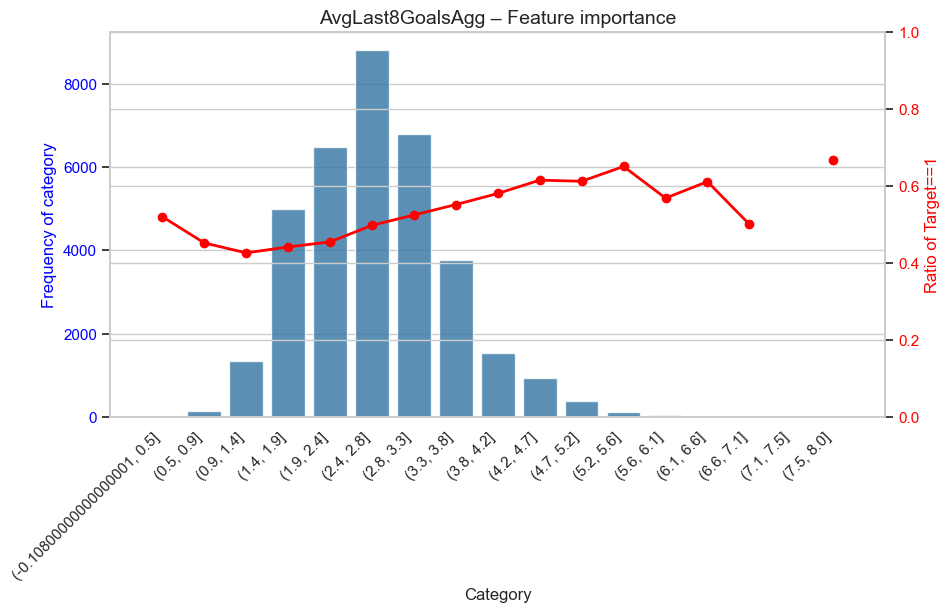

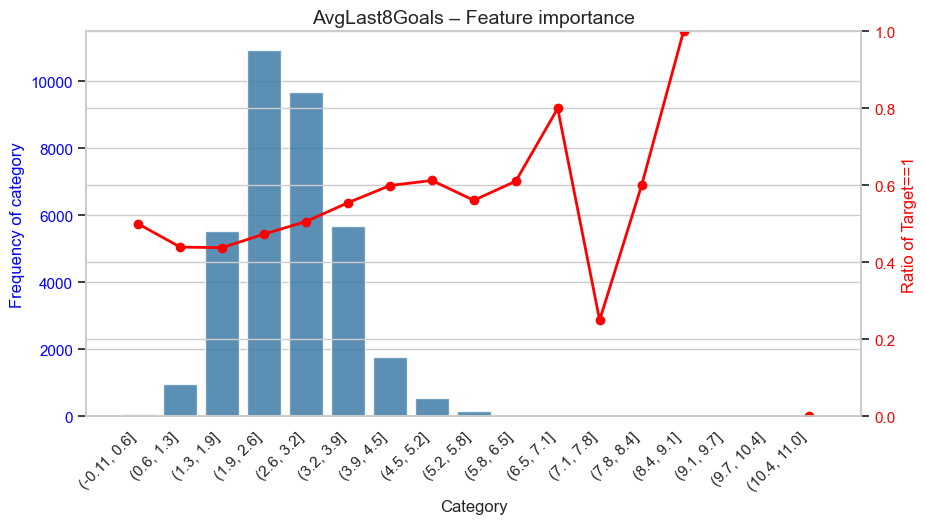

In [98]:
### Graphs showing how each predictor (and its "categories") relates to the target variable
# blue bars = count of observations in each category (for numeric columns, the data is binned; N of bins by Sturges Rule)
# red line = average value of target in each category (P(Target=1 | Category X))

vars = ['B365H', 'B365D', 'B365A', 'B365Cabove2.5', 'B365Cbelow2.5', 'Month', 'IsWeekend', 'TimeNumeric', 'DaysFromSeasonStart', 'DaysSinceLastMatchHome', 'DaysSinceLastMatchAway', 'DaysSinceLastMatchDiff', 'Season', 'AvgLast8HomeGoalsAgg', 'AvgLast8AwayGoalsAgg', 'AvgLast8HomeGoals', 'AvgLast8AwayGoals', 'AvgLast8GoalsAgg', 'AvgLast8Goals']

sns.set_theme(style="whitegrid")

for col in vars:
    plot_df = df[[col,'Target']].dropna(subset=[col,'Target']).copy()

    if pd.api.types.is_numeric_dtype(plot_df[col]):
        N = len(plot_df)
        n_bins = int(np.ceil(1 + np.log2(N))) if N > 0 else 10
        plot_df['Category'] = pd.cut(plot_df[col], bins=n_bins, precision=1, include_lowest=True)
    else:
        plot_df['Category'] = plot_df[col].astype('category')
        
    target_trend = plot_df.groupby('Category')['Target'].mean().reset_index()
    target_trend.columns = ['Category', 'Mean_Target']
    category_counts = plot_df['Category'].value_counts().reset_index()
    category_counts.columns = ['Category', 'Count']
    plot_data_final = pd.merge(category_counts, target_trend, on='Category', how='inner')
    
    if pd.api.types.is_numeric_dtype(df[col]):
        plot_data_final = plot_data_final.sort_values(by='Category')

    x_indices = np.arange(len(plot_data_final)) 
    fig, ax1 = plt.subplots(figsize=(10, 5))
    
    sns.barplot(
        x='Category', 
        y='Count', 
        data=plot_data_final, 
        ax=ax1, 
        color='#1f77b4',
        alpha=0.8
    )
    ax1.set_ylabel('Frequency of category', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    
    ax2 = ax1.twinx()
    ax2.plot(
        x_indices,
        plot_data_final['Mean_Target'], 
        color='red', 
        marker='o', 
        linestyle='-', 
        linewidth=2
    )
    ax2.set_ylabel('Ratio of Target==1', color='red')
    ax2.tick_params(axis='y', labelcolor='red')
    ax2.set_ylim(0, 1)
    
    x_labels = plot_data_final['Category'].astype(str)
    ax1.set_xticklabels(x_labels, rotation=45, ha='right')

    plt.title(f'{col} – Feature importance', fontsize=14)
    plt.show()
    
    # for some reason, it often shows minimum value as negative, even though it's not

## Modelling

We chose only the columns that should officially exist according to the description.

In [99]:
cols_that_exist = [
    "Div", "Date", "Time", "HomeTeam", "AwayTeam", "FTHG", "HG", "FTAG", "AG",
    "FTR", "Res", "HTHG", "HTAG", "HTR", "Attendance", "Referee",
    "HS", "AS", "HST", "AST", "HHW", "AHW", "HC", "AC",
    "HF", "AF", "HFKC", "AFKC", "HO", "AO", "HY", "AY",
    "HR", "AR", "HBP", "ABP", "1XBH", "1XBD", "1XBA", "B365H",
    "B365D", "B365A", "BFH", "BFD", "BFA", "BFDH", "BFDD", "BFDA",
    "BMGMH", "BMGMD", "BMGMA", "BVH", "BVD", "BVA", "BSH", "BSD",
    "BSA", "BWH", "BWD", "BWA", "CLH", "CLD", "CLA", "GBH",
    "GBD", "GBA", "IWH", "IWD", "IWA", "LBH", "LBD", "LBA",
    "PSH", "PH", "PSD", "PD", "PSA", "PA", "SOH", "SOD",
    "SOA", "SBH", "SBD", "SBA", "SJH", "SJD", "SJA", "SYH",
    "SYD", "SYA", "VCH", "VCD", "VCA", "WHH", "WHD", "WHA",
    "Bb1X2", "BbMxH", "BbAvH", "BbMxD", "BbAvD", "BbMxA", "BbAvA",
    "MaxH", "MaxD", "MaxA", "AvgH", "AvgD", "AvgA", "BFEH", "BFED", "BFEA",
    "BbOU", "BbMx>2.5", "BbAv>2.5", "BbMx<2.5", "BbAv<2.5",
    "GB>2.5", "GB<2.5", "B365>2.5", "B365<2.5", "P>2.5", "P<2.5",
    "Max>2.5", "Max<2.5", "Avg>2.5", "Avg<2.5",
    "BbAH", "BbAHh", "BbMxAHH", "BbAvAHH", "BbMxAHA", "BbAvAHA",
    "GBAHH", "GBAHA", "GBAH", "LBAHH", "LBAHA", "LBAH",
    "B365AHH", "B365AHA", "B365AH", "PAHH", "PAHA",
    "MaxAHH", "MaxAHA", "AvgAHH", "AvgAHA", "Season_football"
]

not_used = ['AC', 'AF', 'AR', 'AS', 'AST', 'AY', 'HC', 'HF', 'HR', 'HS', 'HST', 'HTAG', 'HTHG', 'HTR', 'HY']

cols_that_exist = list(set(cols_that_exist) - set(not_used))

Mapping the bets to their market counterpart for the purpose of filling missing values

In [100]:
betting_structure = {
    # --- 1X2 (Match Result) ---
    "H": {
        "max": "MaxH",
        "avg": "AvgH",
        "sources": [
            "1XBH", "B365H", "BFH", "BFDH", "BMGMH", "BVH", "BSH", "BWH", "CLH",
            "GBH", "IWH", "LBH", "PSH", "PH", "SOH", "SBH", "SJH", "SYH",
            "VCH", "WHH", "BbMxH", "BbAvH", "BFEH"
        ]
    },
    "D": {
        "max": "MaxD",
        "avg": "AvgD",
        "sources": [
            "1XBD", "B365D", "BFD", "BFDD", "BMGMD", "BVD", "BSD", "BWD", "CLD",
            "GBD", "IWD", "LBD", "PSD", "PD", "SOD", "SBD", "SJD", "SYD",
            "VCD", "WHD", "BbMxD", "BbAvD", "BFED"
        ]
    },
    "A": {
        "max": "MaxA",
        "avg": "AvgA",
        "sources": [
            "1XBA", "B365A", "BFA", "BFDA", "BMGMA", "BVA", "BSA", "BWA", "CLA",
            "GBA", "IWA", "LBA", "PSA", "PA", "SOA", "SBA", "SJA", "SYA",
            "VCA", "WHA", "BbMxA", "BbAvA", "BFEA"
        ]
    },

    # --- Totals (Over/Under 2.5 Goals) ---
    "Over": {
        "max": "Max>2.5",
        "avg": "Avg>2.5",
        "sources": [
            "BbMx>2.5", "BbAv>2.5", "GB>2.5", "B365>2.5", "P>2.5"
        ]
    },
    "Under": {
        "max": "Max<2.5",
        "avg": "Avg<2.5",
        "sources": [
            "BbMx<2.5", "BbAv<2.5", "GB<2.5", "B365<2.5", "P<2.5"
        ]
    },

    # --- Asian Handicap ---
    "HomeAH": {
        "max": "MaxAHH",
        "avg": "AvgAHH",
        "sources": [
            "BbMxAHH", "BbAvAHH", "GBAHH", "LBAHH", "B365AHH", "PAHH"
        ],
        "handicap_col": ["BbAHh", "BbAH", "AHh"]
    },
    "AwayAH": {
        "max": "MaxAHA",
        "avg": "AvgAHA",
        "sources": [
            "BbMxAHA", "BbAvAHA", "GBAHA", "LBAHA", "B365AHA", "PAHA"
        ],
        "handicap_col": ["BbAHh", "BbAH", "AHh"]
    }
}


For every country, we choose the last season as the test set, with all the previous ones as the train set. This is to avoid breaking up temporal relationships in the data and to allow for sensible rolling averages to be calculated

In [101]:
def load_df(country):
    folder_path = f'data/{country}/'
    folder_paths = [f'data/{i}/' for i in countries]
    folders = [f for f in os.listdir(folder_path) if os.path.isdir(os.path.join(folder_path, f))]

    df = pd.DataFrame()
    folders_full = []
    for i in folder_paths:
        folders_country = [f for f in os.listdir(i) if os.path.isdir(os.path.join(folder_path, f))]
        if len(folders_country) > 0:
            for j in folders_country:
                folders_full.append(i + j + '/')
    divdfs = []
    for i in folders:
        new_folder_path = folder_path + f'{i}/'
        files = [f for f in os.listdir(new_folder_path) if os.path.isfile(os.path.join(new_folder_path, f))]
    
        for j in range(len(files)):
            df = pd.read_csv(new_folder_path + files[j])
            file = files[j]
            df["Season_football"] = os.path.splitext(file)[0]
            divdfs.append(df)
    df = pd.concat(divdfs, ignore_index=True)
    return df
def train_test_split(df):

    seasons = sorted(df["Season_football"].unique())
    last_season = seasons[-1]
    df_train = df[df["Season_football"] != last_season].copy()
    df_test = df[df["Season_football"] == last_season].copy()
    df_train = df_train.drop(columns="Season_football")
    df_test = df_test.drop(columns="Season_football")
    return df_train, df_test

Description of used changed columns:

Date: date as datetime, from this also separately year, month, day and a boolean if the day is weekend

Days since last match: gets the last match of the team both in the position (Home, Away) they are in the current match and regardless of the position

Days since season start: as the seasons did not correspond to the csvs, we assumed that the first match date is approximately when the season starts and calculated it accordingly

Season: season of the year

Target: converts to boolean if above 2.5 or not

Last x matches: gets the average goals of the last x matches of the specific team in specific position, if not applicable, treated as an unknown team and is asigned the moving average

Last x matches agg: same as last x matches but regardless of Home/Away

Referee: encoded as the average of goals in past mathces of the specific referee, if not applicble same procedure as with teams

Bets: missing bets are replaced with corresponding market average, firstly missing market average is calculated from corresponding non-missing bets


In [102]:
def encode_referee_train(df):
    df = df.copy()
    df = df.sort_values('Date').reset_index(drop=True)

    df['TotalGoals'] = df['FTHG'] + df['FTAG']

    df['Referee_encoded'] = (
        df.groupby('Referee')['TotalGoals']
          .transform(lambda x: x.expanding().mean().shift(1))
    )

    df['Referee_encoded'] = df['Referee_encoded'].fillna(
        df['TotalGoals'].expanding().mean().shift(1)
    )

    df.drop(columns='TotalGoals', inplace=True)
    return df
def encode_referee_test(test_df, train_df):
    lastvals = (
        train_df[['Referee', f'Referee_encoded']]
        .dropna()
        .groupby('Referee')[f'Referee_encoded']
        .last()
    )

    test_df['Referee_encoded'] = test_df['Referee'].map(lastvals)
    return test_df

def encode_division_train(df):
    df = df.copy()
    df = df.sort_values('Date').reset_index(drop=True)

    df['TotalGoals'] = df['FTHG'] + df['FTAG']

    df['Div_encoded'] = (
        df.groupby('Div')['TotalGoals']
          .transform(lambda x: x.expanding().mean().shift(1))
    )

    df.drop(columns='TotalGoals', inplace=True)
    return df

def encode_division_test(test_df, train_df):
    lastvals = (
        train_df[['Div', 'Div_encoded']]
        .dropna()
        .groupby('Div')['Div_encoded']
        .last()
    )

    test_df['Div_encoded'] = test_df['Div'].map(lastvals)
    return test_df

In [103]:
def solve_bets_train(df, betting_structure =betting_structure):
    for bet_name, bet in betting_structure.items():
            max_col = bet["max"]
            avg_col = bet["avg"]
            sources = [col for col in bet["sources"] if col in df.columns]
            for col in sources + [max_col, avg_col]:
                if col in df.columns:
                    df[col] = pd.to_numeric(df[col], errors="coerce")
            if sources:
                if max_col not in df.columns:
                    df[max_col] = np.nan
                df[max_col] = df[max_col].fillna(df[sources].max(axis=1, skipna=True))

                if df[max_col].isna().any():
                    vals = df[max_col].copy()
                    running_sum, running_count = 0.0, 0
                    for i in range(len(vals)):
                        if pd.notna(vals.iloc[i]):
                            running_sum += vals.iloc[i]
                            running_count += 1
                        elif running_count > 0:
                            vals.iloc[i] = running_sum / running_count
                    df[max_col] = vals

            if sources:
                if avg_col not in df.columns:
                    df[avg_col] = np.nan
                df[avg_col] = df[avg_col].fillna(df[sources].mean(axis=1, skipna=True))

                if df[avg_col].isna().any():
                    vals = df[avg_col].copy()
                    running_sum, running_count = 0.0, 0
                    for i in range(len(vals)):
                        if pd.notna(vals.iloc[i]):
                            running_sum += vals.iloc[i]
                            running_count += 1
                        elif running_count > 0:
                            vals.iloc[i] = running_sum / running_count
                    df[avg_col] = vals

            if avg_col in df.columns:
                for source in sources:
                    if source in df.columns:
                        na_mask = df[source].isna() & df[avg_col].notna()
                        if na_mask.any():
                            df.loc[na_mask, source] = df.loc[na_mask, avg_col]
    return df

def solve_bets_test(test_df, train_df, betting_structure=betting_structure):
    test_df = test_df.copy()

    for bet_name, bet in betting_structure.items():
        max_col = bet["max"]
        avg_col = bet["avg"]
        sources = [col for col in bet["sources"] if col in test_df.columns]

        # Ensure numeric in test_df
        for col in sources + [max_col, avg_col]:
            if col in test_df.columns:
                test_df[col] = pd.to_numeric(test_df[col], errors="coerce")

        # Ensure numeric in train_df
        numeric_train = train_df[sources].apply(pd.to_numeric, errors='coerce') if sources else pd.DataFrame()

        if sources:
            # Get last known value from train_df per column
            last_max_val = numeric_train.max().max() if not numeric_train.empty else np.nan
            last_avg_val = numeric_train.mean().mean() if not numeric_train.empty else np.nan

            # Fill max_col
            if max_col not in test_df.columns:
                test_df[max_col] = np.nan
            test_df[max_col] = test_df[max_col].fillna(last_max_val)

            # Fill avg_col
            if avg_col not in test_df.columns:
                test_df[avg_col] = np.nan
            test_df[avg_col] = test_df[avg_col].fillna(last_avg_val)

        # Fill missing source columns from avg_col
        if avg_col in test_df.columns:
            for source in sources:
                if source in test_df.columns:
                    na_mask = test_df[source].isna() & test_df[avg_col].notna()
                    test_df.loc[na_mask, source] = test_df.loc[na_mask, avg_col]

    return test_df

def label_teams(train_df, test_df):
    #Label encoding hometeam and awayteam with safe_transform to ensure, that unknown teams from test set are labeled -1
    label_encoder = LabelEncoder()
    all_train_teams = pd.concat([train_df['HomeTeam'], test_df['AwayTeam']]).unique()
    label_encoder.fit(all_train_teams)
    train_df['HomeTeam'] = label_encoder.transform(train_df['HomeTeam'])
    train_df['AwayTeam'] = label_encoder.transform(train_df['AwayTeam'])
    def safe_transform(col):
        return col.apply(lambda x: label_encoder.transform([x])[0] if x in label_encoder.classes_ else -1)
    test_df['HomeTeam'] = safe_transform(test_df['HomeTeam'])
    test_df['AwayTeam'] = safe_transform(test_df['AwayTeam'])
    
    return train_df, test_df

def set_train_test(train_df, test_df, cols=[]):
    train_copy = train_df.copy()
    test_copy = test_df.copy()
    if cols:
        train_copy = train_copy[cols]
        test_copy = test_copy[cols]
    X_train = train_copy.drop(columns=["Target"])
    y_train = train_copy["Target"]
    X_test = test_copy.drop(columns=["Target"])
    y_test = test_copy["Target"]
    
    return X_train, y_train, X_test, y_test

In [104]:
def preprocess_joint(df):
    df = unillegal_columns(df)
    df = to_datetime(df)
    df = days_since_last_match(df)
    df = days_since_season_start(df)
    df = get_season_from_month(df)
    df = add_target_variable(df)
    df = bool_to_int(df)
    return df
def preprocess_train(df,matches):
    if "Referee" in df.columns:
        df = encode_referee_train(df)
    df = encode_division_train(df)
    df = solve_bets_train(df)
    df =last_x_matches_agg(df, x)
    df= last_x_matches(df, x)
    df= new_players_agg(df, x)
    df= new_players(df, x)
    df=last_x_matches_total_agg(df, x)
    df=last_x_matches_total(df, x)
    return df
def preprocess_test(test_df,train_df,matches):
    if "Referee" in test_df.columns:
        test_df = encode_referee_test(test_df, train_df)
    test_df = encode_division_test(test_df, train_df)
    test_df = solve_bets_test(test_df, train_df)
    test_df= last_x_matches_agg_test(test_df, train_df, x)
    test_df= last_x_matches_test(test_df, train_df, x)
    test_df= new_players_test_agg(test_df, train_df, x)
    test_df= new_players_test(test_df, train_df, x)
    test_df= last_x_matches_total_agg(test_df, x)
    test_df= last_x_matches_total(test_df, x)
    return test_df

## Load data

In [105]:
test_all =[]
train_all =[]
for country in countries:
    df = load_df(country)
    train_df, test_df = train_test_split(df)
    train_df = preprocess_joint(train_df)
    test_df = preprocess_joint(test_df)
    train_df = preprocess_train(train_df, matches)
    test_df = preprocess_test(test_df, train_df, matches)
    train_df["Country"] = str(country)
    test_df["Country"] = str(country)
    test_all.append(test_df)
    train_all.append(train_df)

train_all_countries = pd.concat(train_all, ignore_index=True)
test_all_countries = pd.concat(test_all, ignore_index=True)

#Fill last NA values
train_all_countries = train_all_countries[train_all_countries[f"AvgLast{x}Goals"].notna()]
test_all_countries = test_all_countries[test_all_countries[f"AvgLast{x}Goals"].notna()]
for bet_365 in ['B365above2.5', 'B365below2.5']:
    train_all_countries[bet_365] = train_all_countries[bet_365].fillna(train_all_countries[bet_365].mean())
    test_all_countries[bet_365] = test_all_countries[bet_365].fillna(test_all_countries[bet_365].mean())
#train_all_countries.to_csv(f'new_data/all/augmented_test_all.csv', index=False)
#test_all_countries.to_csv(f'new_data/all/augmented_train_all.csv', index=False)

A function allowing us to retrieve the data for any specific country

In [106]:
def get_country_data(country, train_df, test_df):
    train_df = train_df[train_df["Country"] == country]
    test_df = test_df[test_df["Country"] == country]
    return train_df, test_df

Here we separate the usable features into basic and augmented ones, using our calculated columns and columns that won't cause a leakage. We calculated feature importances using the feature_importances notebook.

In [107]:
basic_features = [
    'DaysFromSeasonStart', 'DaysSinceLastMatchHome', 'DaysSinceLastMatchAway', 'DaysSinceLastMatchDiff',
    'Month', 'IsWeekend',
    f'AvgLast{x}HomeGoals', f'AvgLast{x}AwayGoals', f'AvgLast{x}Goals',
    f'AvgLast{x}HomeGoalsAgg', f'AvgLast{x}AwayGoalsAgg',  f'AvgLast{x}GoalsAgg',
    'Target'
    ]
augmented_features = [
    'DaysFromSeasonStart', 'DaysSinceLastMatchHome', 'DaysSinceLastMatchAway', 'DaysSinceLastMatchDiff',
    'Month', 'IsWeekend',
    f'AvgLast{x}HomeGoals', f'AvgLast{x}AwayGoals', f'AvgLast{x}Goals',
    f'AvgLast{x}HomeGoalsAgg', f'AvgLast{x}AwayGoalsAgg',  f'AvgLast{x}GoalsAgg',
    'B365H', 'B365D', 'B365A', 'B365above2.5', 'B365below2.5',
    'Target'
    ]

And here we load train and tests sets with basic features and the data from France, which is a medium size dataset and we'll be using it to pick out which models to use. We originally inteded to use a combined dataset of all countries, but most models handeled that very poorly.

In [108]:
country = "france"
train_set, test_set = get_country_data(country, train_all_countries, test_all_countries)

In [109]:
basic_X_train, basic_y_train, basic_X_test, basic_y_test = set_train_test(train_set, test_set, basic_features)

## Creating a baseline model with a decision tree regression

The first thing we do is define our profit function, so that we can directly see the business impact of the different models

In [110]:
def profit(A, m2=0.03, k=0.3, alpha=1000, epsilon=3,b=12):
    m3 = k*(1-A)
    m1 = 1-m2-m3
    v = alpha * 1 **(-epsilon)
    profit = v * m1 *b
    return profit

Then we create a basic decision tree model with default hyperparametrs as a baseline

In [111]:
baseline_model = DecisionTreeClassifier(random_state=SEED)
baseline_accuracy = accuracy_score(basic_y_test, baseline_model.fit(basic_X_train, basic_y_train).predict(basic_X_test))
print(f"Baseline accuracy: {baseline_accuracy:.4f}")
print(f"Baseline Profit: {profit(baseline_accuracy):.2f}")

Baseline accuracy: 0.4951
Baseline Profit: 9822.35


We can see that the model accuracy is on average rather poor

## Trying different models and hyperparameter tuning

In this part of the work, we'll be trying out different models and tuning their hyperparameters using the optuna library. We'll compare the accuracy of these models on joint data for all countries to decide which model or models to use when looking at the difference between basic and augmented data for individual countries.

### Logistic regression

At first, we'll look at logistic regression. This is mainly to see how much we can improve with just hyperparameter tuning.

We define our objective function for optuna. Essentialy the only hyperparameter we can tune for logistic regression is C, or regularization.

In [112]:
def logreg_objective(trial, X_train, y_train):
    C = trial.suggest_float("C", 0.0001, 100, log=True)
    model = LogisticRegression(C=C, solver="lbfgs", max_iter=1000, random_state=SEED)
    scores = cross_val_score(model, X_train, y_train, cv=10, scoring="accuracy", n_jobs=-1)
    trial.set_user_attr("model", model) 
    return scores.mean()

def get_best_logreg(X_train, y_train, n_trials=100):
    
    study = optuna.create_study(direction='maximize',sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(lambda trial: logreg_objective(trial, X_train, y_train),
               n_trials=n_trials)
    best_model = study.best_trial.user_attrs["model"]
    
    return best_model, study

In [113]:
logreg_model, logreg_study = get_best_logreg(basic_X_train, basic_y_train, n_trials=50)

[I 2025-11-16 12:12:44,911] A new study created in memory with name: no-name-8822fe4f-bfac-404a-a0b2-de110cd1bff7
[I 2025-11-16 12:12:45,031] Trial 0 finished with value: 0.5424599214524852 and parameters: {'C': 0.0008413506881469946}. Best is trial 0 with value: 0.5424599214524852.
[I 2025-11-16 12:12:45,284] Trial 1 finished with value: 0.527973699459181 and parameters: {'C': 2.7561203585239364}. Best is trial 0 with value: 0.5424599214524852.
[I 2025-11-16 12:12:45,419] Trial 2 finished with value: 0.5404680659284059 and parameters: {'C': 0.0038009319222654767}. Best is trial 0 with value: 0.5424599214524852.
[I 2025-11-16 12:12:45,609] Trial 3 finished with value: 0.52740632243111 and parameters: {'C': 0.15938093133708997}. Best is trial 0 with value: 0.5424599214524852.
[I 2025-11-16 12:12:45,669] Trial 4 finished with value: 0.5291116726757662 and parameters: {'C': 0.00012230656663379672}. Best is trial 0 with value: 0.5424599214524852.
[I 2025-11-16 12:12:45,879] Trial 5 finishe

Here we have a plot of the optimization history of the logistic regression

In [114]:
optuna.visualization.plot_optimization_history(logreg_study).show()

And a plot of the accuracy of the logistic regression classifier dependant on the C hyperparameter, we can see the search getting more fine grained near the found optimum

In [115]:
optuna.visualization.plot_parallel_coordinate(logreg_study, params=['C']).show()

We can see that even after the tuning, the accuracy of the logistic regression classifier is higher than that of the baseline decision tree

In [116]:
logreg_model.fit(basic_X_train, basic_y_train)
logreg_pred = logreg_model.predict(basic_X_test)
logreg_accuracy = accuracy_score(basic_y_test, logreg_pred)
print(f"Logistic Regression Test Accuracy: {logreg_accuracy:.4f}")
print(f"Logistic Regression Profit: {profit(logreg_accuracy):.2f}")
print(f"Baseline accuracy: {baseline_accuracy:.4f}")
print(f"Baseline Profit: {profit(baseline_accuracy):.2f}")

Logistic Regression Test Accuracy: 0.5245
Logistic Regression Profit: 9928.24
Baseline accuracy: 0.4951
Baseline Profit: 9822.35


### Random Forest

In [117]:
def random_forest_objective(trial, X_train, y_train):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'random_state': SEED,
        'n_jobs': -1
    }
    model = RandomForestClassifier(**params)
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring="accuracy", n_jobs=-1)
    trial.set_user_attr("model", model)
    return scores.mean()

def get_best_random_forest(X_train, y_train, n_trials=100):
    study = optuna.create_study(direction='maximize',sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(lambda trial: random_forest_objective(trial, X_train, y_train),
               n_trials=n_trials)
    best_model = study.best_trial.user_attrs["model"]
    
    return best_model, study

In [118]:
rf_model, rf_study = get_best_random_forest(basic_X_train, basic_y_train,n_trials=100)

[I 2025-11-16 12:12:51,693] A new study created in memory with name: no-name-7b7c1bfb-4e25-4faa-9507-279bffb9ee12
[I 2025-11-16 12:12:52,149] Trial 0 finished with value: 0.5055399742101869 and parameters: {'n_estimators': 119, 'max_depth': 16, 'min_samples_split': 7, 'min_samples_leaf': 6, 'max_features': 'log2'}. Best is trial 0 with value: 0.5055399742101869.
[I 2025-11-16 12:12:52,419] Trial 1 finished with value: 0.4967246937459703 and parameters: {'n_estimators': 65, 'max_depth': 20, 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 'log2'}. Best is trial 0 with value: 0.5055399742101869.
[I 2025-11-16 12:12:52,607] Trial 2 finished with value: 0.5004166666666666 and parameters: {'n_estimators': 51, 'max_depth': 12, 'min_samples_split': 12, 'min_samples_leaf': 5, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.5055399742101869.
[I 2025-11-16 12:12:52,866] Trial 3 finished with value: 0.5262689393939394 and parameters: {'n_estimators': 59, 'max_depth': 5, 'min_

In [119]:
optuna.visualization.plot_parallel_coordinate(rf_study, params=['max_depth']).show()

In [120]:
optuna.visualization.plot_optimization_history(rf_study).show()

We can see that a tuned random forest model has a substantial improvement in accuracy over the logistic regression

In [121]:
rf_model.fit(basic_X_train, basic_y_train)
rf_pred = rf_model.predict(basic_X_test)
rf_accuracy = accuracy_score(basic_y_test, rf_pred)
print(f"Random Forest Test Accuracy: {rf_accuracy:.4f}")
print(f"Random Forest Profit: {profit(rf_accuracy):.2f}")
print(f"Baseline accuracy: {baseline_accuracy:.4f}")
print(f"Baseline Profit: {profit(baseline_accuracy):.2f}")


Random Forest Test Accuracy: 0.5572
Random Forest Profit: 10045.88
Baseline accuracy: 0.4951
Baseline Profit: 9822.35


### SVM

In [122]:
def svm_objective(trial, X_train, y_train):
    C = trial.suggest_float("svm_C", 1e-2, 1e1, log=True)
    gamma = trial.suggest_float("svm_gamma", 1e-1, 1e2, log=True)
    kernel = trial.suggest_categorical("svm_kernel", ["linear","rbf","sigmoid"])
    model = SVC(C=C, gamma=gamma, kernel=kernel)
    scores = cross_val_score(model, X_train, y_train,cv=5,scoring="accuracy",n_jobs=-1)
    trial.set_user_attr("model", model)
    return scores.mean()

def get_best_svm(X_train, y_train, n_trials=100):
    study = optuna.create_study(direction='maximize',sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(lambda trial: svm_objective(trial, X_train, y_train),
                   n_trials=n_trials)

    best_model = study.best_trial.user_attrs["model"]

    return best_model, study


For a Support Vector Classifier, we have to scale the features for best results

In [123]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(basic_X_train)
X_test_scaled = scaler.transform(basic_X_test)
best_svm, svm_study = get_best_svm(X_train_scaled, basic_y_train, n_trials=50)


[I 2025-11-16 12:14:10,831] A new study created in memory with name: no-name-421e8cb1-e10b-4ec8-81ba-2156bf032415
[I 2025-11-16 12:14:11,552] Trial 0 finished with value: 0.5262709542230818 and parameters: {'svm_C': 0.029006045717177558, 'svm_gamma': 16.601567270965518, 'svm_kernel': 'rbf'}. Best is trial 0 with value: 0.5262709542230818.
[I 2025-11-16 12:14:12,712] Trial 1 finished with value: 0.5254186814958091 and parameters: {'svm_C': 5.704807892772977, 'svm_gamma': 50.36682354798627, 'svm_kernel': 'rbf'}. Best is trial 0 with value: 0.5262709542230818.
[I 2025-11-16 12:14:13,055] Trial 2 finished with value: 0.5200165215989684 and parameters: {'svm_C': 0.07103707305460324, 'svm_gamma': 6.580358474515704, 'svm_kernel': 'linear'}. Best is trial 0 with value: 0.5262709542230818.
[I 2025-11-16 12:14:13,691] Trial 3 finished with value: 0.5262709542230818 and parameters: {'svm_C': 0.3661660555025516, 'svm_gamma': 4.530153310891029, 'svm_kernel': 'rbf'}. Best is trial 0 with value: 0.52

In [124]:
optuna.visualization.plot_optimization_history(svm_study).show()

The SVM performed the worst by far

In [125]:
best_svm.fit(X_train_scaled, basic_y_train)
probs = best_svm.predict(X_test_scaled)
svm_accuracy = accuracy_score(basic_y_test, probs)
print(f"SVM Test Accuracy: {svm_accuracy:.4f}")
print(f"SVM Profit: {profit(svm_accuracy):.2f}")
print(f"Baseline accuracy: {baseline_accuracy:.4f}")
print(f"Baseline Profit: {profit(baseline_accuracy):.2f}")

SVM Test Accuracy: 0.4820
SVM Profit: 9775.29
Baseline accuracy: 0.4951
Baseline Profit: 9822.35


### XGBoost

In [126]:
def xgb_objective(trial, X_train, y_train):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'random_state': SEED,
        'n_jobs': -1,
        'eval_metric': 'logloss'
    }
    model = xgb.XGBClassifier(**params, early_stopping_rounds=50)
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    scores = []
    
    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr = X_train.iloc[train_idx]
        X_val = X_train.iloc[val_idx]
        y_tr = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]
        
        model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
        scores.append(model.score(X_val, y_val))
    trial.set_user_attr("params", params)
    return np.mean(scores)


def get_best_xgb(X_train, y_train, n_trials=100):
    study = optuna.create_study(direction='maximize',sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(lambda trial: xgb_objective(trial, X_train, y_train),
               n_trials=n_trials)
    best_params = study.best_trial.user_attrs["params"]
    best_model = xgb.XGBClassifier(**best_params, use_label_encoder=False)

    return best_model, study

    

In [127]:
xgb_model, xgb_study, = get_best_xgb(basic_X_train, basic_y_train, n_trials=100)

[I 2025-11-16 12:14:43,699] A new study created in memory with name: no-name-26676ae6-7e42-4c51-a20d-7f7aff98c35b
[I 2025-11-16 12:14:44,668] Trial 0 finished with value: 0.5589357672469375 and parameters: {'n_estimators': 238, 'max_depth': 16, 'learning_rate': 0.004490174516996625, 'subsample': 0.8134957573521191, 'colsample_bytree': 0.6058299849941678, 'min_child_weight': 10, 'gamma': 4.503574270585061, 'reg_alpha': 1.9989081956997726e-08, 'reg_lambda': 4.097736483917529}. Best is trial 0 with value: 0.5589357672469375.
[I 2025-11-16 12:14:45,099] Trial 1 finished with value: 0.5399016763378466 and parameters: {'n_estimators': 223, 'max_depth': 8, 'learning_rate': 0.03172061056395256, 'subsample': 0.9776900544212168, 'colsample_bytree': 0.9410942164437139, 'min_child_weight': 1, 'gamma': 2.6061301361014646, 'reg_alpha': 0.0009296911555181726, 'reg_lambda': 0.00023355906230015152}. Best is trial 0 with value: 0.5589357672469375.
[I 2025-11-16 12:14:45,444] Trial 2 finished with value:

In [128]:
optuna.visualization.plot_optimization_history(xgb_study).show()

So far, the XGBoost model and Random Forest have performed similarly well

In [129]:
xgb_model.fit(basic_X_train, basic_y_train)
xgb_pred = xgb_model.predict(basic_X_test)
xgb_accuracy = accuracy_score(basic_y_test, xgb_pred )
print(f"XGBoost Test Accuracy: {xgb_accuracy:.4f}")
print(f"XGBoost Profit: {profit(xgb_accuracy):.2f}")
print(f"Baseline accuracy: {baseline_accuracy:.4f}")
print(f"Baseline Profit: {profit(baseline_accuracy):.2f}")

XGBoost Test Accuracy: 0.5572
XGBoost Profit: 10045.88
Baseline accuracy: 0.4951
Baseline Profit: 9822.35


### ANN network

In [130]:
model = Sequential()
model.add(Dense(128, activation="relu", input_shape=(X_train_scaled.shape[1],)))
model.add(Dropout(0.3))
model.add(Dense(68, activation="relu"))
model.add(Dropout(0.25))
model.add(Dense(32, activation="relu"))
model.add(Dense(1, activation="sigmoid"))  # binary output

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train_scaled, basic_y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=256,
    verbose=1
)

probs = model.predict(X_test_scaled).ravel()
preds = (probs > 0.5).astype(int)






Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.5018 - loss: 0.7014 - val_accuracy: 0.5433 - val_loss: 0.6877
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5423 - loss: 0.6890 - val_accuracy: 0.5305 - val_loss: 0.6894
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5469 - loss: 0.6896 - val_accuracy: 0.5447 - val_loss: 0.6882
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5479 - loss: 0.6872 - val_accuracy: 0.5475 - val_loss: 0.6880
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5511 - loss: 0.6852 - val_accuracy: 0.5461 - val_loss: 0.6876
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5476 - loss: 0.6870 - val_accuracy: 0.5461 - val_loss: 0.6872
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5536 - loss: 0.6874 - val_accuracy: 0.5461 - val_loss: 0.6880
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5632 - loss: 0.6847 - val_accuracy: 0.5532 - val_loss

We created a basic neural network to try out, however it performed poorly

In [131]:
nn_acc =  accuracy_score(basic_y_test, preds)
print(f"Neural Network Test Accuracy: {nn_acc:.4f}")
print(f"Neural Network Profit: {profit(nn_acc):.2f}")
print(f"Baseline accuracy: {baseline_accuracy:.4f}")
print(f"Baseline Profit: {profit(baseline_accuracy):.2f}")

Neural Network Test Accuracy: 0.5294
Neural Network Profit: 9945.88
Baseline accuracy: 0.4951
Baseline Profit: 9822.35


## Different features games

We can try to count only with bets

In [132]:
columns3 = [
    'DaysFromSeasonStart', 'DaysSinceLastMatchHome', 'DaysSinceLastMatchAway', 'DaysSinceLastMatchDiff',
    'Month', 
    'B365H', 'B365D', 'B365A', 'B365above2.5', 'B365below2.5',
    'Target'
]
X_train, y_train, X_test, y_test = set_train_test(train_set, test_set, cols=columns3)

In [133]:
xgb_model, xgb_study, = get_best_xgb(X_train, y_train, n_trials=100)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
print(baseline_accuracy)
print(accuracy_score(y_test, xgb_pred))

[I 2025-11-16 12:15:41,570] A new study created in memory with name: no-name-de69bba8-f03e-4033-82d5-59492ff9eb71
[I 2025-11-16 12:15:42,516] Trial 0 finished with value: 0.5785287717601548 and parameters: {'n_estimators': 238, 'max_depth': 16, 'learning_rate': 0.004490174516996625, 'subsample': 0.8134957573521191, 'colsample_bytree': 0.6058299849941678, 'min_child_weight': 10, 'gamma': 4.503574270585061, 'reg_alpha': 1.9989081956997726e-08, 'reg_lambda': 4.097736483917529}. Best is trial 0 with value: 0.5785287717601548.
[I 2025-11-16 12:15:42,936] Trial 1 finished with value: 0.5558087524177949 and parameters: {'n_estimators': 223, 'max_depth': 8, 'learning_rate': 0.03172061056395256, 'subsample': 0.9776900544212168, 'colsample_bytree': 0.9410942164437139, 'min_child_weight': 1, 'gamma': 2.6061301361014646, 'reg_alpha': 0.0009296911555181726, 'reg_lambda': 0.00023355906230015152}. Best is trial 0 with value: 0.5785287717601548.
[I 2025-11-16 12:15:43,247] Trial 2 finished with value:

0.4950980392156863
0.5686274509803921


In [134]:
columns4 = [
    'DaysFromSeasonStart', 'DaysSinceLastMatchHome', 'DaysSinceLastMatchAway', 'DaysSinceLastMatchDiff',
    'Month', 'IsWeekend',
    f'AvgLast{x}HomeGoals', f'AvgLast{x}AwayGoals', f'AvgLast{x}Goals',
    f'AvgLast{x}HomeGoalsAgg', f'AvgLast{x}AwayGoalsAgg',  f'AvgLast{x}GoalsAgg',
    'Target'
    ]
X_train, y_train, X_test, y_test = set_train_test(train_set, test_set, cols=columns4)

In [135]:
xgb_model, xgb_study = get_best_xgb(X_train, y_train, n_trials=100)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
print(baseline_accuracy)
print(accuracy_score(y_test, xgb_pred))

[I 2025-11-16 12:16:49,242] A new study created in memory with name: no-name-48ec2173-6fa4-48d4-baa8-17fde007cd3f
[I 2025-11-16 12:16:50,194] Trial 0 finished with value: 0.5589357672469375 and parameters: {'n_estimators': 238, 'max_depth': 16, 'learning_rate': 0.004490174516996625, 'subsample': 0.8134957573521191, 'colsample_bytree': 0.6058299849941678, 'min_child_weight': 10, 'gamma': 4.503574270585061, 'reg_alpha': 1.9989081956997726e-08, 'reg_lambda': 4.097736483917529}. Best is trial 0 with value: 0.5589357672469375.
[I 2025-11-16 12:16:50,580] Trial 1 finished with value: 0.5399016763378466 and parameters: {'n_estimators': 223, 'max_depth': 8, 'learning_rate': 0.03172061056395256, 'subsample': 0.9776900544212168, 'colsample_bytree': 0.9410942164437139, 'min_child_weight': 1, 'gamma': 2.6061301361014646, 'reg_alpha': 0.0009296911555181726, 'reg_lambda': 0.00023355906230015152}. Best is trial 0 with value: 0.5589357672469375.
[I 2025-11-16 12:16:50,887] Trial 2 finished with value:

0.4950980392156863
0.5571895424836601


We can see, that results are very similar, due to high strenght of bet values influence

In [136]:
optuna.visualization.plot_optimization_history(xgb_study).show()

# Final results

Due to the results from the previous sections, we decided to use Random Forest and XGBoost models for the final profit calculation

In [137]:
increase_by_country = {
    key: {'best_basic_acc': 0, 'best_augmented_acc': 0, "best_basic_model": "", "best_augmented_model": "","best_basic_params": {}, "best_augmented_params": {}}
    for key in countries
}

For every country, we run both a Random Forest and an XGBoost optimizer, once for basic data and once for augmented data. Then we save the best model and it's accuracy for both datasets for each country and calculate the profit gain from augmented data

In [138]:
for country in countries:
    optuna.logging.set_verbosity(optuna.logging.CRITICAL)
    train_set, test_set = get_country_data(country, train_all_countries, test_all_countries)
    basic_X_train, basic_y_train, basic_X_test, basic_y_test = set_train_test(train_set, test_set,cols=basic_features)
    augmented_X_train, augmented_y_train,augmented_X_test, augmented_y_test = set_train_test(train_set, test_set,cols=augmented_features)
    basic_xgb_model, basic_xgb_study, = get_best_xgb(basic_X_train, basic_y_train, n_trials=100)
    augmented_xgb_model, augmented_xgb_study, = get_best_xgb(augmented_X_train, augmented_y_train, n_trials=100)
    basic_xgb_model.fit(basic_X_train, basic_y_train)
    basic_xgb_pred = basic_xgb_model.predict(basic_X_test)
    augmented_xgb_model.fit(augmented_X_train, augmented_y_train)
    augmented_xgb_pred = augmented_xgb_model.predict(augmented_X_test)
   
    acc_a = accuracy_score(basic_y_test, basic_xgb_pred)
    acc_b = accuracy_score(augmented_y_test, augmented_xgb_pred)
    profit_b = profit(acc_b)
    profit_a = profit(acc_a)
    if acc_a > increase_by_country[country]['best_basic_acc']:
        increase_by_country[country]['best_basic_acc'] = acc_a
        increase_by_country[country]['best_basic_model'] = "XGBoost"
        increase_by_country[country]['best_basic_params'] = basic_xgb_study.best_params
    if acc_b > increase_by_country[country]['best_augmented_acc']:
        increase_by_country[country]['best_augmented_acc'] = acc_b
        increase_by_country[country]['best_augmented_model'] = "XGBoost"
        increase_by_country[country]['best_augmented_params'] = augmented_xgb_study.best_params


In [139]:
for country in countries:
    optuna.logging.set_verbosity(optuna.logging.CRITICAL)
    train_set, test_set = get_country_data(country, train_all_countries, test_all_countries)
    basic_X_train, basic_y_train, basic_X_test, basic_y_test = set_train_test(train_set, test_set,cols=basic_features)
    augmented_X_train, augmented_y_train,augmented_X_test, augmented_y_test = set_train_test(train_set, test_set,cols=augmented_features)
    basic_rf_model, basic_rf_study, = get_best_random_forest(basic_X_train, basic_y_train, n_trials=100)
    augmented_rf_model, augmented_rf_study, = get_best_random_forest(augmented_X_train, augmented_y_train, n_trials=100)
    basic_rf_model.fit(basic_X_train, basic_y_train)
    basic_rf_pred = basic_rf_model.predict(basic_X_test)
    augmented_rf_model.fit(augmented_X_train, augmented_y_train)
    augmented_rf_pred = augmented_rf_model.predict(augmented_X_test)
   
    acc_a = accuracy_score(basic_y_test, basic_rf_pred)
    acc_b = accuracy_score(augmented_y_test, augmented_rf_pred)
    profit_b = profit(acc_b)
    profit_a = profit(acc_a)
    if acc_a > increase_by_country[country]['best_basic_acc']:
        increase_by_country[country]['best_basic_acc'] = acc_a
        increase_by_country[country]['best_basic_model'] = "RandomForest"
        increase_by_country[country]['best_basic_params'] = basic_rf_study.best_params
    if acc_b > increase_by_country[country]['best_augmented_acc']:
        increase_by_country[country]['best_augmented_acc'] = acc_b
        increase_by_country[country]['best_augmented_model'] = "RandomForest"
        increase_by_country[country]['best_augmented_params'] = augmented_rf_study.best_params

In [140]:
for country in increase_by_country:
    print(f"Country: {country}")
    print(f"Best found model with basic data was: {increase_by_country[country]['best_basic_model']} with accuracy {increase_by_country[country]['best_basic_acc']:.4f} and profit {profit(increase_by_country[country]['best_basic_acc']):.2f}.")
    print(f"Best found model with augmented data was: {increase_by_country[country]['best_augmented_model']} with accuracy {increase_by_country[country]['best_augmented_acc']:.4f} and profit {profit(increase_by_country[country]['best_augmented_acc']):.2f}.")
    print(f"Thus, the mount of money we're willing to pay for augmented data for {country} is: {profit(increase_by_country[country]['best_augmented_acc']) - profit(increase_by_country[country]['best_basic_acc']):.2f}")
    print("__________________________________________")

Country: belgium
Best found model with basic data was: RandomForest with accuracy 0.5128 and profit 9886.15.
Best found model with augmented data was: RandomForest with accuracy 0.5481 and profit 10013.08.
Thus, the mount of money we're willing to pay for augmented data for belgium is: 126.92
__________________________________________
Country: england
Best found model with basic data was: RandomForest with accuracy 0.5388 and profit 9979.69.
Best found model with augmented data was: RandomForest with accuracy 0.5609 and profit 10059.25.
Thus, the mount of money we're willing to pay for augmented data for england is: 79.57
__________________________________________
Country: france
Best found model with basic data was: XGBoost with accuracy 0.5572 and profit 10045.88.
Best found model with augmented data was: RandomForest with accuracy 0.5735 and profit 10104.71.
Thus, the mount of money we're willing to pay for augmented data for france is: 58.82
________________________________________

Here we can see several interesting things. 
Germany and Portugal were the only countries where we were able to achieve models with an accuracy above 0.6.
The most accurate model was Random Forest the majority of the time, however 2/3 models with accuracy above 0.6 were XGBoost.
The highest profit gain from augmented data was in Spain.
In Scotland, our accuracy actually decreased with the augmented data.
